In [1]:
# ============================================================================
# CELL 1: IMPORTS & SETUP
# ============================================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("Imports OK")

Imports OK


In [2]:
# ============================================================================
# CELL 2: CONSTANTS
# ============================================================================
VALID_LEAGUES = ['Premier League', 'Ligue 1', 'Bundesliga', 'Serie A', 'La Liga']
LEAGUE_MAP = {
    'Ligue 1':        0,
    'Bundesliga':     1,
    'Serie A':        2,
    'La Liga':        3,
    'Premier League': 4,
}
LEAGUE_MAP_REVERSE = {v: k for k, v in LEAGUE_MAP.items()}
LEAGUE_ABBREV = {
    'Premier League': 'PL',
    'La Liga':        'LL',
    'Bundesliga':     'BL',
    'Serie A':        'SA',
    'Ligue 1':        'L1',
}

STATS_ATT_MID = ['KP', 'PrgP', 'PrgC', 'SCA']
STATS_DEF     = ['TklW', 'Int', 'Clr', 'Blocks']

POS_STAT_MAP = {
    'FWD': STATS_ATT_MID,
    'MID': STATS_ATT_MID,
    'DEF': STATS_DEF,
}

TRAIN_SEASONS = [
    '2017_2018', '2018_2019', '2019_2020',
    '2020_2021', '2021_2022', '2022_2023', '2023_2024',
]
EXCLUDED_TRANSFER_SEASONS = {
    '2022_2023_to_2023_2024',
    '2023_2024_to_2024_2025',
}

EXCLUDE_INTRA_LEAGUE = True

# MIN_90S is the primary sensitivity parameter.
# Default = 5.0 (used for all main results).
# Sensitivity sweep in Cell 7c: [3.0, 4.0, 5.0, 6.0, 7.0]
MIN_90S = 5.0

EPS = 0.05

# MIN_90S values for sensitivity sweep
MIN_90S_SWEEP = [3.0, 4.0, 5.0, 6.0, 7.0]

print("Constants OK")
print(f"MIN_90S = {MIN_90S}  |  EPS = {EPS}")
print(f"MIN_90S sensitivity sweep: {MIN_90S_SWEEP}")

Constants OK
MIN_90S = 5.0  |  EPS = 0.05
MIN_90S sensitivity sweep: [3.0, 4.0, 5.0, 6.0, 7.0]


In [3]:
# ============================================================================
# CELL 3: HELPER FUNCTIONS
# ============================================================================
def normalize_name(x: str) -> str:
    x = unicodedata.normalize('NFKD', str(x))
    x = x.encode('ascii', 'ignore').decode('ascii')
    return x.replace(' ', '').lower()


def bucket_position(pos: str) -> str:
    primary = str(pos).upper().split(',')[0].strip()
    if primary == 'GK':
        return 'GK'
    elif 'D' in primary:
        return 'DEF'
    elif 'M' in primary:
        return 'MID'
    elif 'F' in primary:
        return 'FWD'
    return 'OTHER'


def _standardize_league_and_position(df: pd.DataFrame) -> pd.DataFrame:
    df['Comp'] = (
        df['Comp']
        .astype(str)
        .str.replace(r'^[a-z]{2,3}\s+', '', regex=True)
        .str.strip()
    )
    df['Comp'] = df['Comp'].replace({'eng Premier League': 'Premier League'})
    df['Pos_Bucket'] = df['Pos'].apply(bucket_position)
    return df


def _load_base_historical(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={
        'player': 'Player',
        'squad':  'Squad',
        'comp':   'Comp',
        'pos':    'Pos',
        'age':    'Age',
    })
    # 'Avg Mins per Match' is total season minutes — divide by 90 for 90s
    df['90s'] = pd.to_numeric(
        df['Avg Mins per Match'], errors='coerce'
    ).fillna(0) / 90.0
    return df


def _load_base_modern(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    if '90s' not in df.columns and 'Min' in df.columns:
        df['90s'] = pd.to_numeric(df['Min'], errors='coerce').fillna(0) / 90.0
    return df


print("Helpers OK")

Helpers OK


In [6]:
# ============================================================================
# CELL 4: SEASON LOADING FUNCTION
# ============================================================================
def load_season_all(path: str, is_historical: bool,
                    stats_list: list,
                    min_90s_prefilter: float = None) -> pd.DataFrame:
    """
    Load a season CSV retaining all Big Five leagues and all positions.
    min_90s_prefilter: loose pre-filter applied here; bridge enforces MIN_90S.
    If None, uses max(1.0, MIN_90S - 2.0) as the default loose pre-filter.
    """
    if min_90s_prefilter is None:
        min_90s_prefilter = max(1.0, MIN_90S - 2.0)

    if is_historical:
        df = _load_base_historical(path)

        if 'KP' in stats_list:
            df['KP'] = pd.to_numeric(
                df.get('Key passes', 0), errors='coerce').fillna(0)
        if 'PrgP' in stats_list:
            df['PrgP'] = pd.to_numeric(
                df.get('Progressive Passes', 0), errors='coerce').fillna(0)
        if 'PrgC' in stats_list:
            df['PrgC'] = pd.to_numeric(
                df.get('Progressive Carries', 0), errors='coerce').fillna(0)
        if 'SCA' in stats_list:
            df['SCA'] = (
                pd.to_numeric(
                    df.get('Shot creating actions p 90', 0),
                    errors='coerce').fillna(0)
                * df['90s']
            )
        if 'TklW' in stats_list:
            df['TklW'] = pd.to_numeric(
                df.get('Tackles Won', 0), errors='coerce').fillna(0)
        if 'Int' in stats_list:
            df['Int'] = pd.to_numeric(
                df.get('Interceptions', 0), errors='coerce').fillna(0)
        if 'Clr' in stats_list:
            df['Clr'] = pd.to_numeric(
                df.get('Clearances', 0), errors='coerce').fillna(0)
        if 'Blocks' in stats_list:
            shots_blk  = pd.to_numeric(
                df.get('Shots blocked', 0), errors='coerce').fillna(0)
            passes_blk = pd.to_numeric(
                df.get('Passes blocked', 0), errors='coerce').fillna(0)
            df['Blocks'] = shots_blk + passes_blk
    else:
        df = _load_base_modern(path)

        if 'KP' in stats_list:
            df['KP'] = pd.to_numeric(
                df.get('KP', df.get('KP_stats_passing', 0)),
                errors='coerce').fillna(0)
        if 'PrgP' in stats_list:
            df['PrgP'] = pd.to_numeric(
                df.get('PrgP', df.get('PrgP_stats_passing', 0)),
                errors='coerce').fillna(0)
        if 'PrgC' in stats_list:
            df['PrgC'] = pd.to_numeric(
                df.get('PrgC', df.get('PrgC_stats_possession', 0)),
                errors='coerce').fillna(0)
        if 'SCA' in stats_list:
            if 'SCA' in df.columns:
                df['SCA'] = pd.to_numeric(df['SCA'], errors='coerce').fillna(0)
            elif 'SCA90' in df.columns:
                df['SCA'] = (pd.to_numeric(df['SCA90'], errors='coerce').fillna(0)
                             * df['90s'])
            else:
                df['SCA'] = 0.0
        if 'TklW' in stats_list:
            df['TklW'] = pd.to_numeric(
                df.get('TklW', df.get('TklW_stats_misc', 0)),
                errors='coerce').fillna(0)
        if 'Int' in stats_list:
            df['Int'] = pd.to_numeric(
                df.get('Int', df.get('Int_stats_misc', 0)),
                errors='coerce').fillna(0)
        if 'Clr' in stats_list:
            df['Clr'] = pd.to_numeric(
                df.get('Clr', df.get('Clr_stats_defense', 0)),
                errors='coerce').fillna(0)
        if 'Blocks' in stats_list:
            if 'Blocks_stats_defense' in df.columns:
                df['Blocks'] = pd.to_numeric(
                    df['Blocks_stats_defense'], errors='coerce').fillna(0)
            elif 'Blocks' in df.columns:
                df['Blocks'] = pd.to_numeric(
                    df['Blocks'], errors='coerce').fillna(0)
            else:
                df['Blocks'] = 0.0

    for stat in stats_list:
        if stat not in df.columns:
            df[stat] = 0.0
        else:
            df[stat] = pd.to_numeric(df[stat], errors='coerce').fillna(0)

    df = _standardize_league_and_position(df)
    df = df[df['Comp'].isin(VALID_LEAGUES)]
    df = df[df['90s'] >= min_90s_prefilter]
    df['Player_Key'] = df['Player'].apply(normalize_name)
    df['Age']        = pd.to_numeric(df['Age'], errors='coerce')
    keep = (['Player', 'Player_Key', 'Squad', 'Comp', 'Pos',
              'Pos_Bucket', 'Age', '90s'] + stats_list)
    keep = [c for c in keep if c in df.columns]
    return df[keep].reset_index(drop=True)

print("load_season_all defined")

load_season_all defined


In [7]:
# ============================================================================
# CELL 4b: UEFA COEFFICIENT LOOKUP & JOIN
# ============================================================================
# Annual season coefficients sourced directly from UEFA.com
# (Association Club Coefficients table, verified from screenshots).
# These are per-season average points (total pts ÷ clubs participating),
# NOT the 5-year rolling total.
#
# The delta = trg_coeff - src_coeff encodes the competitive step
# a player makes: positive = moving to a stronger league,
# negative = moving to a weaker league.
#
# Join key: (source_year_of_transfer_season, league_name)
# e.g. '2017_2018_to_2018_2019' → src_season = '2017_2018'
#                                → trg_season = '2018_2019'

UEFA_COEFFS = {
    # season_string         league              annual coeff
    ('2017_2018', 'Premier League'): 20.071,
    ('2017_2018', 'La Liga'):        19.714,
    ('2017_2018', 'Bundesliga'):      9.857,
    ('2017_2018', 'Serie A'):        17.333,
    ('2017_2018', 'Ligue 1'):        11.500,

    ('2018_2019', 'Premier League'): 22.642,
    ('2018_2019', 'La Liga'):        19.571,
    ('2018_2019', 'Bundesliga'):     15.214,
    ('2018_2019', 'Serie A'):        12.642,
    ('2018_2019', 'Ligue 1'):        10.583,

    ('2019_2020', 'Premier League'): 18.571,
    ('2019_2020', 'La Liga'):        18.928,
    ('2019_2020', 'Bundesliga'):     18.714,
    ('2019_2020', 'Serie A'):        14.928,
    ('2019_2020', 'Ligue 1'):        11.666,

    ('2020_2021', 'Premier League'): 24.357,
    ('2020_2021', 'La Liga'):        19.500,
    ('2020_2021', 'Bundesliga'):     15.214,
    ('2020_2021', 'Serie A'):        16.285,
    ('2020_2021', 'Ligue 1'):         7.916,

    ('2021_2022', 'Premier League'): 21.000,
    ('2021_2022', 'La Liga'):        18.428,
    ('2021_2022', 'Bundesliga'):     16.214,
    ('2021_2022', 'Serie A'):        15.714,
    ('2021_2022', 'Ligue 1'):        18.416,

    ('2022_2023', 'Premier League'): 23.000,
    ('2022_2023', 'La Liga'):        16.571,
    ('2022_2023', 'Bundesliga'):     17.125,
    ('2022_2023', 'Serie A'):        22.357,
    ('2022_2023', 'Ligue 1'):        12.583,

    ('2023_2024', 'Premier League'): 17.375,
    ('2023_2024', 'La Liga'):        16.062,
    ('2023_2024', 'Bundesliga'):     19.357,
    ('2023_2024', 'Serie A'):        21.000,
    ('2023_2024', 'Ligue 1'):        16.250,

    ('2024_2025', 'Premier League'): 29.464,
    ('2024_2025', 'La Liga'):        23.892,
    ('2024_2025', 'Bundesliga'):     18.421,
    ('2024_2025', 'Serie A'):        21.875,
    ('2024_2025', 'Ligue 1'):        17.928,
}

def add_uefa_coeffs(df: pd.DataFrame) -> pd.DataFrame:
    """
    Join UEFA annual season coefficients to a bridge DataFrame and compute
    the competitive strength delta (trg - src).

    Parameters
    ----------
    df : bridge DataFrame with columns Transfer_Season, League_src, League_trg

    Returns
    -------
    df with three new columns:
        UEFA_coeff_src   : source league coefficient for the source season
        UEFA_coeff_trg   : target league coefficient for the target season
        UEFA_coeff_delta : trg - src  (positive = step up, negative = step down)
    """
    df = df.copy()

    # Extract individual season strings from transfer season label
    src_seasons = df['Transfer_Season'].str.split('_to_').str[0]
    trg_seasons = df['Transfer_Season'].str.split('_to_').str[1]

    df['UEFA_coeff_src'] = [
        UEFA_COEFFS.get((s, l), np.nan)
        for s, l in zip(src_seasons, df['League_src'])
    ]
    df['UEFA_coeff_trg'] = [
        UEFA_COEFFS.get((s, l), np.nan)
        for s, l in zip(trg_seasons, df['League_trg'])
    ]
    df['UEFA_coeff_delta'] = df['UEFA_coeff_trg'] - df['UEFA_coeff_src']

    # Audit — flag any missing lookups
    n_missing = df['UEFA_coeff_src'].isna().sum() + df['UEFA_coeff_trg'].isna().sum()
    if n_missing > 0:
        print(f"  WARNING: {n_missing} missing UEFA coefficient lookups:")
        bad = df[df['UEFA_coeff_src'].isna() | df['UEFA_coeff_trg'].isna()]
        print(bad[['Player', 'Transfer_Season', 'League_src', 'League_trg']].to_string())
    else:
        print(f"  OK — {len(df)} rows joined. "
              f"UEFA_coeff_delta range: "
              f"[{df['UEFA_coeff_delta'].min():.3f}, "
              f"{df['UEFA_coeff_delta'].max():.3f}]  "
              f"mean: {df['UEFA_coeff_delta'].mean():.3f}")
    return df

print("UEFA coefficient helpers defined")

UEFA coefficient helpers defined


In [13]:
# ============================================================================
# CELL 5: BRIDGE CONSTRUCTION FUNCTION
# ============================================================================
def build_ml_bridge(
    data_dict:    dict,
    stats_list:   list,
    seasons:      list,
    label:        str   = 'BRIDGE',
    pos_filter:   list  = None,
    dest_leagues: list  = None,
    verbose:      bool  = True,
    min_90s:      float = None,   # ← new parameter; None = use global MIN_90S
) -> pd.DataFrame:
    """
    Build a position-specific ML bridge over Big Five → Big Five transfers.
    min_90s: playing time threshold; defaults to global MIN_90S if None.
    """
    if dest_leagues is None:
        dest_leagues = VALID_LEAGUES
    if min_90s is None:
        min_90s = MIN_90S       # use global default

    rows = []
    for i in range(len(seasons) - 1):
        s0, s1          = seasons[i], seasons[i + 1]
        transfer_season = f'{s0}_to_{s1}'
        if transfer_season in EXCLUDED_TRANSFER_SEASONS:
            if verbose:
                print(f"  Skipping excluded pair: {transfer_season}")
            continue
        if s0 not in data_dict or s1 not in data_dict:
            if verbose:
                print(f"  WARNING: missing data for {s0}/{s1}, skipping.")
            continue

        d0, d1 = data_dict[s0], data_dict[s1]
        merged = pd.merge(d0, d1, on='Player_Key', suffixes=('_src', '_trg'))

        if verbose:
            gk_rows = merged[merged['Pos_Bucket_src'].isin(['GK', 'OTHER'])]
            if len(gk_rows) > 0:
                print(f"  [{transfer_season}] GK/OTHER before filter: "
                      f"{len(gk_rows)} rows")

        merged = merged[merged['Squad_src'] != merged['Squad_trg']]
        merged = merged[merged['Comp_trg'].isin(dest_leagues)]
        if EXCLUDE_INTRA_LEAGUE:
            merged = merged[merged['Comp_src'] != merged['Comp_trg']]
        merged = merged[merged['90s_src'] >= min_90s]   # ← uses parameter
        merged = merged[merged['90s_trg'] >= min_90s]   # ← uses parameter
        if pos_filter is not None:
            merged = merged[merged['Pos_Bucket_src'].isin(pos_filter)]
        if len(merged) == 0:
            continue

        for _, r in merged.iterrows():
            row = {
                'Player':          r['Player_src'],
                'Player_Key':      r['Player_Key'],
                'Age':             r['Age_src'],
                'Pos':             r['Pos_src'],
                'Pos_Bucket':      r['Pos_Bucket_src'],
                'Squad_src':       r['Squad_src'],
                'Squad_trg':       r['Squad_trg'],
                'League_src':      r['Comp_src'],
                'League_trg':      r['Comp_trg'],
                'League_ID_src':   LEAGUE_MAP[r['Comp_src']],
                'League_ID_trg':   LEAGUE_MAP[r['Comp_trg']],
                '90s_src':         r['90s_src'],
                '90s_trg':         r['90s_trg'],
                'Transfer_Season': transfer_season,
            }
            for stat in stats_list:
                src_val  = r.get(f'{stat}_src', 0.0)
                trg_val  = r.get(f'{stat}_trg', 0.0)
                src_rate = src_val / r['90s_src'] if r['90s_src'] > 0 else 0.0
                trg_rate = trg_val / r['90s_trg'] if r['90s_trg'] > 0 else 0.0
                row[f'{stat}_src_per90'] = src_rate
                row[f'{stat}_trg_per90'] = trg_rate
                row[f'log_ratio_{stat}'] = np.log(
                    (trg_rate + EPS) / (src_rate + EPS)
                )
            rows.append(row)

    df = pd.DataFrame(rows)
    if verbose and len(df) > 0:
        print(f"\n  [{label}] Total transfers: {len(df)}")
        pair_counts = (
            df.groupby(['League_src', 'League_trg'])
            .size().reset_index(name='n')
            .sort_values('n', ascending=False)
        )
        for _, row in pair_counts.iterrows():
            src_a = LEAGUE_ABBREV[row['League_src']]
            trg_a = LEAGUE_ABBREV[row['League_trg']]
            print(f"    {src_a} → {trg_a}: {row['n']:>3d}")
    return df.reset_index(drop=True)

print("build_ml_bridge defined")

build_ml_bridge defined


In [14]:
# ============================================================================
# CELL 6: LOAD ALL SEASONS
# ============================================================================
# ATT+MID and DEF stats loaded separately per season to match bridge stat lists.
# Each season is loaded twice — once per stat group. Slight redundancy but
# keeps the data contract clean and avoids mixed-stat DataFrames.

print("Loading ATT+MID season data...")
data_att_mid = {}
for s in TRAIN_SEASONS:
    data_att_mid[s] = load_season_all(
        f'players_data-{s}.csv',
        is_historical=True,
        stats_list=STATS_ATT_MID,
    )
    print(f"  {s}: {len(data_att_mid[s])} player-seasons")

print("\nLoading DEF season data...")
data_def = {}
for s in TRAIN_SEASONS:
    data_def[s] = load_season_all(
        f'players_data-{s}.csv',
        is_historical=True,
        stats_list=STATS_DEF,
    )
    print(f"  {s}: {len(data_def[s])} player-seasons")

print("\nLoading 2024/25 (modern format)...")
df_2425_att_mid = load_season_all(
    'players_data-2024_2025.csv',
    is_historical=False,
    stats_list=STATS_ATT_MID,
)
df_2425_def = load_season_all(
    'players_data-2024_2025.csv',
    is_historical=False,
    stats_list=STATS_DEF,
)
print(f"  2024_2025 ATT+MID: {len(df_2425_att_mid)} player-seasons")
print(f"  2024_2025 DEF:     {len(df_2425_def)} player-seasons")

print("\nAll seasons loaded.")

Loading ATT+MID season data...
  2017_2018: 2153 player-seasons
  2018_2019: 2122 player-seasons
  2019_2020: 2137 player-seasons
  2020_2021: 2192 player-seasons
  2021_2022: 2233 player-seasons
  2022_2023: 2216 player-seasons
  2023_2024: 2168 player-seasons

Loading DEF season data...
  2017_2018: 2153 player-seasons
  2018_2019: 2122 player-seasons
  2019_2020: 2137 player-seasons
  2020_2021: 2192 player-seasons
  2021_2022: 2233 player-seasons
  2022_2023: 2216 player-seasons
  2023_2024: 2168 player-seasons

Loading 2024/25 (modern format)...
  2024_2025 ATT+MID: 2214 player-seasons
  2024_2025 DEF:     2214 player-seasons

All seasons loaded.


In [15]:
# ============================================================================
# CELL 7: BUILD TRAINING BRIDGES — SEPARATE PER POSITION GROUP
# ============================================================================
print("=" * 70)
print("BUILDING TRAINING BRIDGES")
print("Cross-league only | All Big Five destinations | FWD / MID / DEF separate")
print("=" * 70 + "\n")

df_bridge_fwd = build_ml_bridge(
    data_att_mid,
    stats_list=STATS_ATT_MID,
    seasons=TRAIN_SEASONS,
    label='TRAIN_FWD',
    pos_filter=['FWD'],
    dest_leagues=None,
    verbose=True,
)
df_bridge_fwd['Pos_Group'] = 'FWD'

print()

df_bridge_mid = build_ml_bridge(
    data_att_mid,
    stats_list=STATS_ATT_MID,
    seasons=TRAIN_SEASONS,
    label='TRAIN_MID',
    pos_filter=['MID'],
    dest_leagues=None,
    verbose=True,
)
df_bridge_mid['Pos_Group'] = 'MID'

print()

df_bridge_def = build_ml_bridge(
    data_def,
    stats_list=STATS_DEF,
    seasons=TRAIN_SEASONS,
    label='TRAIN_DEF',
    pos_filter=['DEF'],
    dest_leagues=None,
    verbose=True,
)
df_bridge_def['Pos_Group'] = 'DEF'

print("\n" + "=" * 70)
print("TRAINING BRIDGE SUMMARY")
print("=" * 70)
print(f"  FWD: {len(df_bridge_fwd):>4d} transfers | stats: {STATS_ATT_MID}")
print(f"  MID: {len(df_bridge_mid):>4d} transfers | stats: {STATS_ATT_MID}")
print(f"  DEF: {len(df_bridge_def):>4d} transfers | stats: {STATS_DEF}")
print(f"  Total: {len(df_bridge_fwd) + len(df_bridge_mid) + len(df_bridge_def):>4d} transfers")

BUILDING TRAINING BRIDGES
Cross-league only | All Big Five destinations | FWD / MID / DEF separate

  [2017_2018_to_2018_2019] GK/OTHER before filter: 106 rows
  [2018_2019_to_2019_2020] GK/OTHER before filter: 107 rows
  [2019_2020_to_2020_2021] GK/OTHER before filter: 112 rows
  [2020_2021_to_2021_2022] GK/OTHER before filter: 114 rows
  [2021_2022_to_2022_2023] GK/OTHER before filter: 106 rows
  Skipping excluded pair: 2022_2023_to_2023_2024

  [TRAIN_FWD] Total transfers: 202
    BL → PL:  20
    PL → SA:  17
    LL → PL:  16
    PL → LL:  15
    L1 → SA:  14
    LL → SA:  13
    L1 → PL:  12
    SA → LL:  11
    L1 → BL:  10
    L1 → LL:  10
    BL → LL:   9
    LL → L1:   9
    SA → PL:   8
    SA → BL:   8
    SA → L1:   7
    BL → SA:   7
    BL → L1:   6
    PL → L1:   5
    PL → BL:   3
    LL → BL:   2

  [2017_2018_to_2018_2019] GK/OTHER before filter: 106 rows
  [2018_2019_to_2019_2020] GK/OTHER before filter: 107 rows
  [2019_2020_to_2020_2021] GK/OTHER before filter: 112

In [16]:
# ============================================================================
# CELL 7b: BRIDGE INTEGRITY ASSERTIONS
# ============================================================================
print("Running bridge integrity checks...\n")

for label, df, expected_stats, expected_pos in [
    ('FWD', df_bridge_fwd, STATS_ATT_MID, {'FWD'}),
    ('MID', df_bridge_mid, STATS_ATT_MID, {'MID'}),
    ('DEF', df_bridge_def, STATS_DEF,     {'DEF'}),
]:
    print(f"--- {label} bridge ---")

    # Position purity
    actual_pos = set(df['Pos_Bucket'].unique())
    assert actual_pos == expected_pos, \
        f"Position contamination: expected {expected_pos}, got {actual_pos}"
    print(f"  Position purity:       OK {actual_pos}")

    # No GK or OTHER
    assert 'GK'    not in df['Pos_Bucket'].values, f"GK found in {label} bridge"
    assert 'OTHER' not in df['Pos_Bucket'].values, f"OTHER found in {label} bridge"
    print(f"  No GK/OTHER:           OK")

    # Correct stat columns present
    for stat in expected_stats:
        assert f'{stat}_src_per90' in df.columns, \
            f"Missing {stat}_src_per90 in {label} bridge"
        assert f'log_ratio_{stat}' in df.columns, \
            f"Missing log_ratio_{stat} in {label} bridge"
    print(f"  Expected stats present: OK {expected_stats}")

    # Wrong stat columns absent
    wrong_stats = STATS_DEF if label in ('FWD', 'MID') else STATS_ATT_MID
    for stat in wrong_stats:
        assert f'{stat}_src_per90' not in df.columns, \
            f"Wrong stat {stat}_src_per90 found in {label} bridge"
    print(f"  Wrong stats absent:    OK")

    # Cross-league only
    intra = df[df['League_src'] == df['League_trg']]
    assert len(intra) == 0, \
        f"Intra-league transfers found in {label} bridge: {len(intra)}"
    print(f"  Cross-league only:     OK")

    # Temporal holdout
    leaked = set(df['Transfer_Season']) & EXCLUDED_TRANSFER_SEASONS
    assert len(leaked) == 0, f"TEST SEASON LEAK in {label}: {leaked}"
    print(f"  Temporal holdout:      OK")

    print(f"  Rows: {len(df)} | Cols: {len(df.columns)}\n")

print("All bridge integrity assertions passed.")

Running bridge integrity checks...

--- FWD bridge ---
  Position purity:       OK {'FWD'}
  No GK/OTHER:           OK
  Expected stats present: OK ['KP', 'PrgP', 'PrgC', 'SCA']
  Wrong stats absent:    OK
  Cross-league only:     OK
  Temporal holdout:      OK
  Rows: 202 | Cols: 27

--- MID bridge ---
  Position purity:       OK {'MID'}
  No GK/OTHER:           OK
  Expected stats present: OK ['KP', 'PrgP', 'PrgC', 'SCA']
  Wrong stats absent:    OK
  Cross-league only:     OK
  Temporal holdout:      OK
  Rows: 255 | Cols: 27

--- DEF bridge ---
  Position purity:       OK {'DEF'}
  No GK/OTHER:           OK
  Expected stats present: OK ['TklW', 'Int', 'Clr', 'Blocks']
  Wrong stats absent:    OK
  Cross-league only:     OK
  Temporal holdout:      OK
  Rows: 257 | Cols: 27

All bridge integrity assertions passed.


S4: MIN_90S SENSITIVITY SWEEP
Sweep values: [3.0, 4.0, 5.0, 6.0, 7.0]

--- MIN_90S = 3.0 ---
  Train: FWD=238  MID=290  DEF=305  total=833
  Test:  FWD=113  MID=136  DEF=161  total=410
  Sparse pairs (n<5): 3  (n<3): 1
  Mean log-ratio: mean=-0.0632  std=0.5198

--- MIN_90S = 4.0 ---
  Train: FWD=218  MID=274  DEF=281  total=773
  Test:  FWD=98  MID=125  DEF=144  total=367
  Sparse pairs (n<5): 4  (n<3): 1
  Mean log-ratio: mean=-0.0598  std=0.4991

--- MIN_90S = 5.0 ---
  Train: FWD=202  MID=255  DEF=257  total=714
  Test:  FWD=82  MID=109  DEF=135  total=326
  Sparse pairs (n<5): 4  (n<3): 2
  Mean log-ratio: mean=-0.0531  std=0.4864

--- MIN_90S = 6.0 ---
  Train: FWD=172  MID=234  DEF=234  total=640
  Test:  FWD=76  MID=97  DEF=123  total=296
  Sparse pairs (n<5): 4  (n<3): 3
  Mean log-ratio: mean=-0.0534  std=0.4583

--- MIN_90S = 7.0 ---
  Train: FWD=154  MID=212  DEF=215  total=581
  Test:  FWD=65  MID=92  DEF=115  total=272
  Sparse pairs (n<5): 6  (n<3): 5
  Mean log-ratio: m

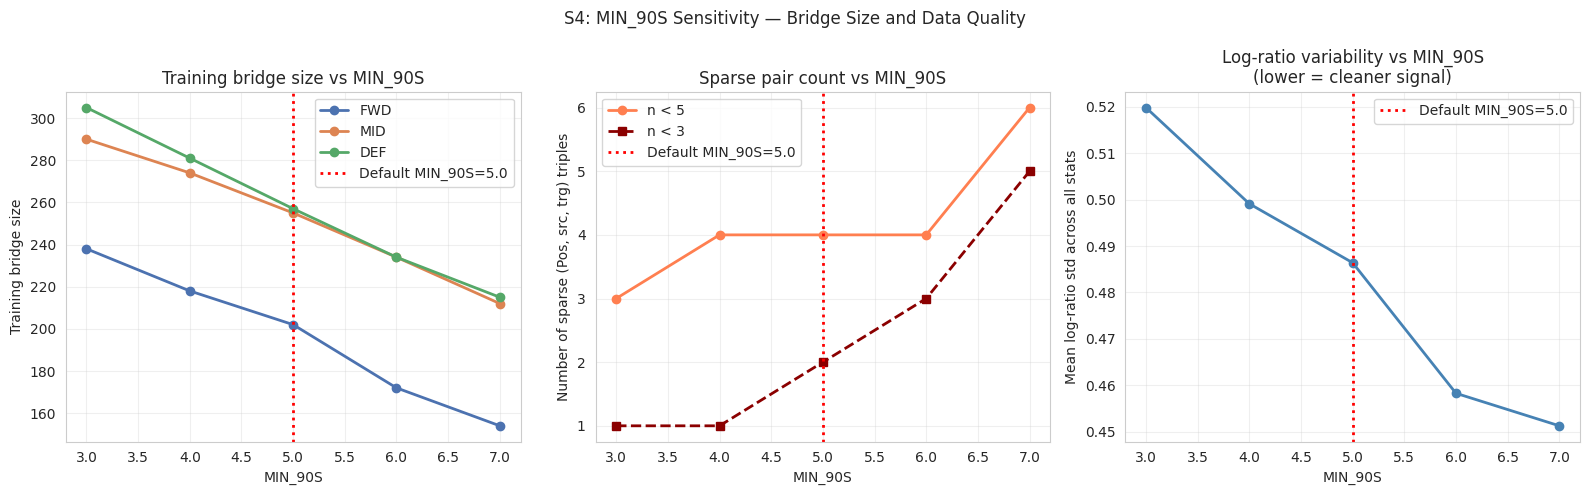


Saved: ml_sensitivity_min90s.csv

Note: to run full modelling sensitivity, set SAVE_SWEEP_BRIDGES=True,
then re-run modelling notebook with each bridge directory as input.


In [17]:
# ============================================================================
# CELL 7c: MIN_90S SENSITIVITY SWEEP
# ============================================================================
# Rebuilds all 6 bridges (3 train + 3 test) at each MIN_90S threshold
# and records bridge sizes and log-ratio distribution statistics.
# Does NOT re-run the modelling notebook — that is done separately
# by saving the bridges at each threshold and running Cell 1–16 fresh.
#
# This cell produces:
#   (1) Bridge size table — how many transfers at each threshold
#   (2) Log-ratio distribution stats — do mean/std change materially?
#   (3) Sparse pair counts — how many pairs drop below n=5 or n=3?
#   (4) Saves bridges for each threshold to separate subdirectories
#       (optional — set SAVE_SWEEP_BRIDGES = True to enable)
#
# Main results use MIN_90S = 5.0 (set in Cell 2).
# Sensitivity sweep: 3.0, 4.0, 5.0, 6.0, 7.0

SAVE_SWEEP_BRIDGES = False   # set True to save CSVs for each threshold

import os
S4_RESULTS = []

print("=" * 70)
print("S4: MIN_90S SENSITIVITY SWEEP")
print(f"Sweep values: {MIN_90S_SWEEP}")
print("=" * 70)

for min_val in MIN_90S_SWEEP:
    print(f"\n--- MIN_90S = {min_val} ---")

    # Rebuild all training bridges at this threshold
    sweep_fwd = build_ml_bridge(
        data_att_mid, stats_list=STATS_ATT_MID,
        seasons=TRAIN_SEASONS,
        label=f'SWEEP_FWD_{min_val}',
        pos_filter=['FWD'], dest_leagues=None,
        verbose=False, min_90s=min_val,
    )
    sweep_mid = build_ml_bridge(
        data_att_mid, stats_list=STATS_ATT_MID,
        seasons=TRAIN_SEASONS,
        label=f'SWEEP_MID_{min_val}',
        pos_filter=['MID'], dest_leagues=None,
        verbose=False, min_90s=min_val,
    )
    sweep_def = build_ml_bridge(
        data_def, stats_list=STATS_DEF,
        seasons=TRAIN_SEASONS,
        label=f'SWEEP_DEF_{min_val}',
        pos_filter=['DEF'], dest_leagues=None,
        verbose=False, min_90s=min_val,
    )

    # Rebuild test bridges at this threshold
    _orig_excl = set(EXCLUDED_TRANSFER_SEASONS)
    EXCLUDED_TRANSFER_SEASONS.clear()

    sweep_test_fwd_c1 = build_ml_bridge(
        {'2022_2023': data_att_mid['2022_2023'],
         '2023_2024': data_att_mid['2023_2024']},
        stats_list=STATS_ATT_MID,
        seasons=['2022_2023', '2023_2024'],
        pos_filter=['FWD'], dest_leagues=None,
        verbose=False, min_90s=min_val,
    )
    sweep_test_fwd_c2 = build_ml_bridge(
        {'2023_2024': data_att_mid['2023_2024'],
         '2024_2025': df_2425_att_mid},
        stats_list=STATS_ATT_MID,
        seasons=['2023_2024', '2024_2025'],
        pos_filter=['FWD'], dest_leagues=None,
        verbose=False, min_90s=min_val,
    )
    sweep_test_mid_c1 = build_ml_bridge(
        {'2022_2023': data_att_mid['2022_2023'],
         '2023_2024': data_att_mid['2023_2024']},
        stats_list=STATS_ATT_MID,
        seasons=['2022_2023', '2023_2024'],
        pos_filter=['MID'], dest_leagues=None,
        verbose=False, min_90s=min_val,
    )
    sweep_test_mid_c2 = build_ml_bridge(
        {'2023_2024': data_att_mid['2023_2024'],
         '2024_2025': df_2425_att_mid},
        stats_list=STATS_ATT_MID,
        seasons=['2023_2024', '2024_2025'],
        pos_filter=['MID'], dest_leagues=None,
        verbose=False, min_90s=min_val,
    )
    sweep_test_def_c1 = build_ml_bridge(
        {'2022_2023': data_def['2022_2023'],
         '2023_2024': data_def['2023_2024']},
        stats_list=STATS_DEF,
        seasons=['2022_2023', '2023_2024'],
        pos_filter=['DEF'], dest_leagues=None,
        verbose=False, min_90s=min_val,
    )
    sweep_test_def_c2 = build_ml_bridge(
        {'2023_2024': data_def['2023_2024'],
         '2024_2025': df_2425_def},
        stats_list=STATS_DEF,
        seasons=['2023_2024', '2024_2025'],
        pos_filter=['DEF'], dest_leagues=None,
        verbose=False, min_90s=min_val,
    )

    EXCLUDED_TRANSFER_SEASONS.update(_orig_excl)

    sweep_test_fwd = pd.concat(
        [sweep_test_fwd_c1, sweep_test_fwd_c2], ignore_index=True)
    sweep_test_mid = pd.concat(
        [sweep_test_mid_c1, sweep_test_mid_c2], ignore_index=True)
    sweep_test_def = pd.concat(
        [sweep_test_def_c1, sweep_test_def_c2], ignore_index=True)

    # Bridge sizes
    n_train = len(sweep_fwd) + len(sweep_mid) + len(sweep_def)
    n_test  = len(sweep_test_fwd) + len(sweep_test_mid) + len(sweep_test_def)

    # Sparse pair counts (training bridges)
    all_train_sweep = pd.concat([
        sweep_fwd.assign(Pos='FWD'),
        sweep_mid.assign(Pos='MID'),
        sweep_def.assign(Pos='DEF'),
    ], ignore_index=True)
    pair_counts = (
        all_train_sweep.groupby(['Pos', 'League_src', 'League_trg'])
        .size().reset_index(name='n')
    )
    sparse_lt5  = (pair_counts['n'] < 5).sum()
    sparse_lt3  = (pair_counts['n'] < 3).sum()
    zero_pairs  = (pair_counts['n'] == 0).sum()

    # Log-ratio distribution stats (all stats, all pos groups)
    lr_means, lr_stds = [], []
    for df_sw, stats_l in [
        (sweep_fwd, STATS_ATT_MID),
        (sweep_mid, STATS_ATT_MID),
        (sweep_def, STATS_DEF),
    ]:
        for stat in stats_l:
            col = f'log_ratio_{stat}'
            if col in df_sw.columns and len(df_sw) > 0:
                lr_means.append(df_sw[col].mean())
                lr_stds.append(df_sw[col].std())

    mean_lr_mean = np.mean(lr_means)
    mean_lr_std  = np.mean(lr_stds)

    S4_RESULTS.append({
        'min_90s':       min_val,
        'n_train_fwd':   len(sweep_fwd),
        'n_train_mid':   len(sweep_mid),
        'n_train_def':   len(sweep_def),
        'n_train_total': n_train,
        'n_test_fwd':    len(sweep_test_fwd),
        'n_test_mid':    len(sweep_test_mid),
        'n_test_def':    len(sweep_test_def),
        'n_test_total':  n_test,
        'sparse_lt5':    sparse_lt5,
        'sparse_lt3':    sparse_lt3,
        'mean_lr_mean':  round(mean_lr_mean, 4),
        'mean_lr_std':   round(mean_lr_std,  4),
    })

    print(f"  Train: FWD={len(sweep_fwd)}  MID={len(sweep_mid)}  "
          f"DEF={len(sweep_def)}  total={n_train}")
    print(f"  Test:  FWD={len(sweep_test_fwd)}  "
          f"MID={len(sweep_test_mid)}  "
          f"DEF={len(sweep_test_def)}  total={n_test}")
    print(f"  Sparse pairs (n<5): {sparse_lt5}  "
          f"(n<3): {sparse_lt3}")
    print(f"  Mean log-ratio: mean={mean_lr_mean:.4f}  "
          f"std={mean_lr_std:.4f}")

    # Optionally save bridges for this threshold
    if SAVE_SWEEP_BRIDGES:
        sweep_dir = f'bridges_min90s_{min_val}'
        os.makedirs(sweep_dir, exist_ok=True)
        sweep_fwd.to_csv(f'{sweep_dir}/ml_bridge_train_fwd.csv', index=False)
        sweep_mid.to_csv(f'{sweep_dir}/ml_bridge_train_mid.csv', index=False)
        sweep_def.to_csv(f'{sweep_dir}/ml_bridge_train_def.csv', index=False)
        sweep_test_fwd.to_csv(f'{sweep_dir}/ml_bridge_test_fwd.csv', index=False)
        sweep_test_mid.to_csv(f'{sweep_dir}/ml_bridge_test_mid.csv', index=False)
        sweep_test_def.to_csv(f'{sweep_dir}/ml_bridge_test_def.csv', index=False)
        print(f"  Saved to {sweep_dir}/")

df_s4 = pd.DataFrame(S4_RESULTS)

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n\nSUMMARY TABLE")
print("=" * 70)
print(df_s4[['min_90s', 'n_train_total', 'n_test_total',
              'sparse_lt5', 'sparse_lt3',
              'mean_lr_mean', 'mean_lr_std']].to_string(index=False))

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('S4: MIN_90S Sensitivity — Bridge Size and Data Quality',
             fontsize=12)

# Bridge sizes
for label, col, color in [
    ('FWD', 'n_train_fwd', '#4c72b0'),
    ('MID', 'n_train_mid', '#dd8452'),
    ('DEF', 'n_train_def', '#55a868'),
]:
    axes[0].plot(df_s4['min_90s'], df_s4[col],
                 'o-', color=color, lw=2, label=label)
axes[0].axvline(MIN_90S, color='red', linestyle=':', lw=2,
                label=f'Default MIN_90S={MIN_90S}')
axes[0].set_xlabel('MIN_90S')
axes[0].set_ylabel('Training bridge size')
axes[0].set_title('Training bridge size vs MIN_90S')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Sparse pair count
axes[1].plot(df_s4['min_90s'], df_s4['sparse_lt5'],
             'o-', color='coral', lw=2, label='n < 5')
axes[1].plot(df_s4['min_90s'], df_s4['sparse_lt3'],
             's--', color='darkred', lw=2, label='n < 3')
axes[1].axvline(MIN_90S, color='red', linestyle=':', lw=2,
                label=f'Default MIN_90S={MIN_90S}')
axes[1].set_xlabel('MIN_90S')
axes[1].set_ylabel('Number of sparse (Pos, src, trg) triples')
axes[1].set_title('Sparse pair count vs MIN_90S')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Log-ratio std
axes[2].plot(df_s4['min_90s'], df_s4['mean_lr_std'],
             'o-', color='steelblue', lw=2)
axes[2].axvline(MIN_90S, color='red', linestyle=':', lw=2,
                label=f'Default MIN_90S={MIN_90S}')
axes[2].set_xlabel('MIN_90S')
axes[2].set_ylabel('Mean log-ratio std across all stats')
axes[2].set_title('Log-ratio variability vs MIN_90S\n'
                  '(lower = cleaner signal)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

df_s4.to_csv('ml_sensitivity_min90s.csv', index=False)
print("\nSaved: ml_sensitivity_min90s.csv")
print("\nNote: to run full modelling sensitivity, set SAVE_SWEEP_BRIDGES=True,")
print("then re-run modelling notebook with each bridge directory as input.")

In [18]:
# ============================================================================
# CELL 8: BUILD HELD-OUT TEST BRIDGES — POSITION SEPARATED
# ============================================================================
print("=" * 70)
print("BUILDING HELD-OUT TEST BRIDGES")
print("Cohort 1: 2022/23 → 2023/24  |  Cohort 2: 2023/24 → 2024/25")
print("=" * 70 + "\n")

# Temporarily lift exclusion to build test bridges
_orig_excl = set(EXCLUDED_TRANSFER_SEASONS)
EXCLUDED_TRANSFER_SEASONS.clear()

test_configs = [
    ('FWD', STATS_ATT_MID, data_att_mid,
     {**{'2022_2023': data_att_mid['2022_2023'],
         '2023_2024': data_att_mid['2023_2024']}},
     {**{'2023_2024': data_att_mid['2023_2024'],
         '2024_2025': df_2425_att_mid}}),
    ('MID', STATS_ATT_MID, data_att_mid,
     {**{'2022_2023': data_att_mid['2022_2023'],
         '2023_2024': data_att_mid['2023_2024']}},
     {**{'2023_2024': data_att_mid['2023_2024'],
         '2024_2025': df_2425_att_mid}}),
    ('DEF', STATS_DEF, data_def,
     {**{'2022_2023': data_def['2022_2023'],
         '2023_2024': data_def['2023_2024']}},
     {**{'2023_2024': data_def['2023_2024'],
         '2024_2025': df_2425_def}}),
]

df_test_fwd = None
df_test_mid = None
df_test_def = None

for pos_group, stats_list, _, data_c1, data_c2 in test_configs:
    print(f"\n--- {pos_group} ---")

    c1 = build_ml_bridge(
        data_c1,
        stats_list=stats_list,
        seasons=['2022_2023', '2023_2024'],
        label=f'TEST_C1_{pos_group}',
        pos_filter=[pos_group],
        dest_leagues=None,
        verbose=True,
    )
    c1['Test_Cohort'] = 'C1_2223_2324'
    c1['Pos_Group']   = pos_group

    c2 = build_ml_bridge(
        data_c2,
        stats_list=stats_list,
        seasons=['2023_2024', '2024_2025'],
        label=f'TEST_C2_{pos_group}',
        pos_filter=[pos_group],
        dest_leagues=None,
        verbose=True,
    )
    c2['Test_Cohort'] = 'C2_2324_2425'
    c2['Pos_Group']   = pos_group

    combined = pd.concat([c1, c2], ignore_index=True)
    print(f"\n  {pos_group} combined test: {len(combined)} transfers "
          f"(C1: {len(c1)}, C2: {len(c2)})")

    if pos_group == 'FWD':
        df_test_fwd = combined
    elif pos_group == 'MID':
        df_test_mid = combined
    elif pos_group == 'DEF':
        df_test_def = combined

# Restore exclusion set
EXCLUDED_TRANSFER_SEASONS.update(_orig_excl)

print("\n" + "=" * 70)
print("TEST BRIDGE SUMMARY")
print("=" * 70)
print(f"  FWD test: {len(df_test_fwd):>4d} transfers")
print(f"  MID test: {len(df_test_mid):>4d} transfers")
print(f"  DEF test: {len(df_test_def):>4d} transfers")

BUILDING HELD-OUT TEST BRIDGES
Cohort 1: 2022/23 → 2023/24  |  Cohort 2: 2023/24 → 2024/25


--- FWD ---
  [2022_2023_to_2023_2024] GK/OTHER before filter: 111 rows

  [TEST_C1_FWD] Total transfers: 48
    L1 → BL:   6
    LL → PL:   5
    PL → BL:   4
    LL → SA:   4
    LL → L1:   4
    BL → LL:   3
    PL → LL:   3
    BL → PL:   3
    SA → PL:   3
    PL → SA:   2
    BL → SA:   2
    PL → L1:   2
    L1 → SA:   2
    BL → L1:   1
    L1 → LL:   1
    LL → BL:   1
    L1 → PL:   1
    SA → L1:   1
  [2023_2024_to_2024_2025] GK/OTHER before filter: 107 rows

  [TEST_C2_FWD] Total transfers: 34
    LL → SA:   5
    BL → PL:   4
    L1 → BL:   3
    L1 → SA:   3
    LL → PL:   2
    L1 → LL:   2
    BL → LL:   2
    SA → PL:   2
    L1 → PL:   2
    PL → LL:   2
    PL → L1:   2
    SA → L1:   2
    BL → L1:   1
    PL → BL:   1
    SA → LL:   1

  FWD combined test: 82 transfers (C1: 48, C2: 34)

--- MID ---
  [2022_2023_to_2023_2024] GK/OTHER before filter: 111 rows

  [TEST_C1_MID

In [19]:
# ============================================================================
# CELL 8b: APPLY UEFA COEFFICIENTS TO ALL BRIDGES
# ============================================================================
# Joins UEFA annual season coefficients to all 6 bridges (3 training, 3 test).
# Requires: add_uefa_coeffs() defined in Cell 4b.
# Must run after Cell 8 (test bridges built).

print("Joining UEFA coefficients to training bridges...")
df_bridge_fwd = add_uefa_coeffs(df_bridge_fwd)
df_bridge_mid = add_uefa_coeffs(df_bridge_mid)
df_bridge_def = add_uefa_coeffs(df_bridge_def)

print("\nJoining UEFA coefficients to test bridges...")
df_test_fwd = add_uefa_coeffs(df_test_fwd)
df_test_mid = add_uefa_coeffs(df_test_mid)
df_test_def = add_uefa_coeffs(df_test_def)

# ── Sanity check ──────────────────────────────────────────────────────────────
print("\nSample delta values — FWD training bridge (first 5 rows):")
print(df_bridge_fwd[['Player', 'League_src', 'League_trg',
                      'UEFA_coeff_src', 'UEFA_coeff_trg',
                      'UEFA_coeff_delta']].head())

print("\nDelta distribution by bridge:")
for label, df in [('FWD', df_bridge_fwd), ('MID', df_bridge_mid), ('DEF', df_bridge_def)]:
    d = df['UEFA_coeff_delta']
    print(f"  {label}: mean={d.mean():.3f}  std={d.std():.3f}  "
          f"min={d.min():.3f}  max={d.max():.3f}  null={d.isna().sum()}")

Joining UEFA coefficients to training bridges...
  OK — 202 rows joined. UEFA_coeff_delta range: [-11.012, 12.785]  mean: 1.266
  OK — 255 rows joined. UEFA_coeff_delta range: [-11.012, 13.084]  mean: 1.132
  OK — 257 rows joined. UEFA_coeff_delta range: [-11.012, 13.084]  mean: 1.687

Joining UEFA coefficients to test bridges...
  OK — 82 rows joined. UEFA_coeff_delta range: [-6.938, 13.402]  mean: 2.651
  OK — 109 rows joined. UEFA_coeff_delta range: [-6.938, 13.402]  mean: 2.398
  OK — 135 rows joined. UEFA_coeff_delta range: [-6.938, 13.402]  mean: 2.472

Sample delta values — FWD training bridge (first 5 rows):
                      Player  League_src      League_trg  UEFA_coeff_src  \
0            Felipe Anderson     Serie A  Premier League          17.333   
1              Florin Andone     La Liga  Premier League          19.714   
2  Pierre-Emerick Aubameyang  Bundesliga  Premier League           9.857   
3                Keita Baldé     Ligue 1         Serie A          11.500

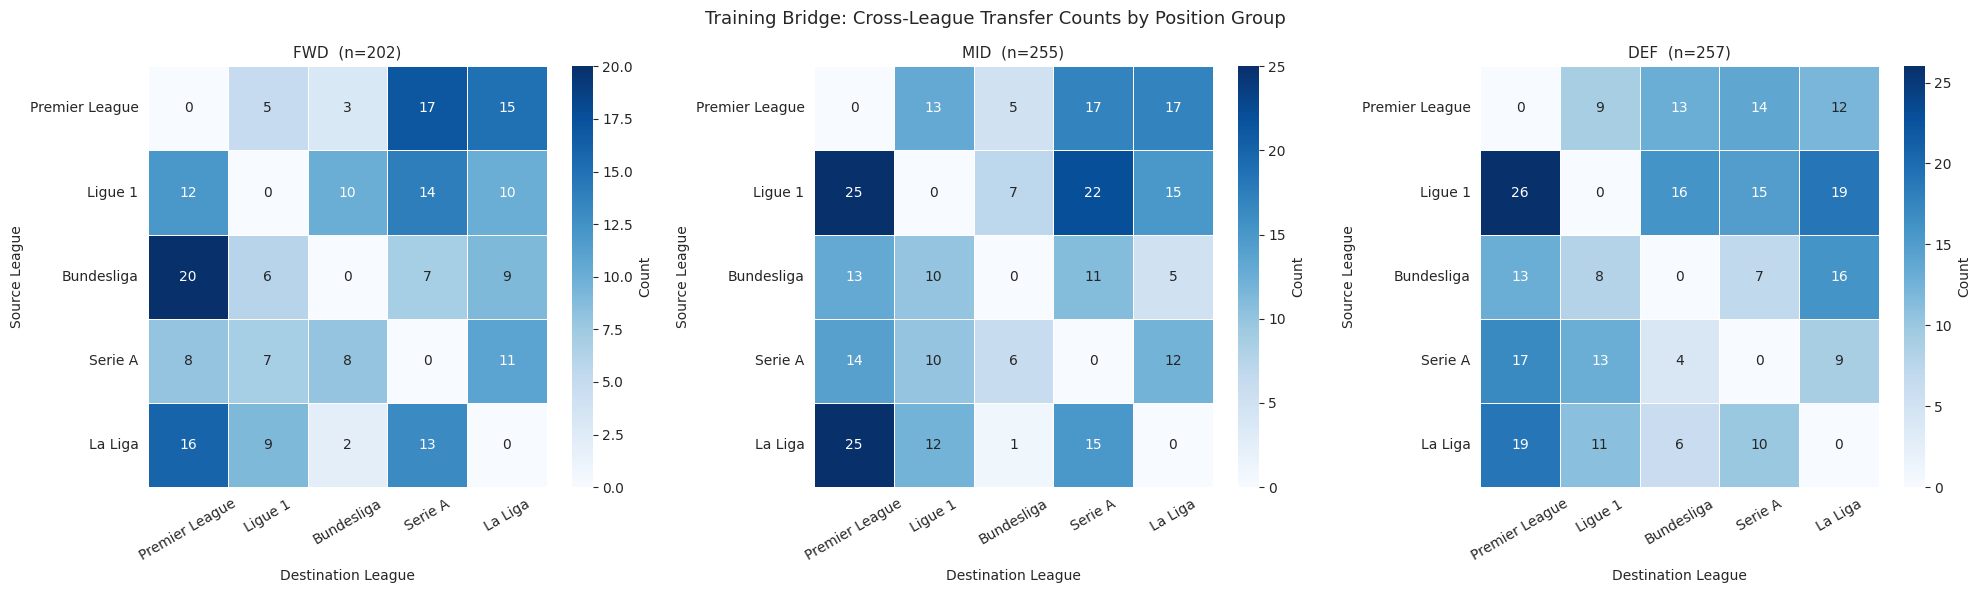

In [20]:
# ============================================================================
# CELL 9: EDA — BRIDGE COMPOSITION HEATMAP
# ============================================================================
# Transfer counts per src→trg league pair, one panel per position group.

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Training Bridge: Cross-League Transfer Counts by Position Group',
    fontsize=13
)

for ax, (label, df) in zip(axes, [
    ('FWD', df_bridge_fwd),
    ('MID', df_bridge_mid),
    ('DEF', df_bridge_def),
]):
    pair_matrix = (
        df.groupby(['League_src', 'League_trg'])
          .size()
          .unstack(fill_value=0)
          .reindex(index=VALID_LEAGUES, columns=VALID_LEAGUES, fill_value=0)
    )
    sns.heatmap(
        pair_matrix, annot=True, fmt='d', cmap='Blues',
        linewidths=0.5, ax=ax,
        cbar_kws={'label': 'Count'},
    )
    ax.set_title(f'{label}  (n={len(df)})', fontsize=11)
    ax.set_xlabel('Destination League')
    ax.set_ylabel('Source League')
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [21]:
# ============================================================================
# CELL 9b: EDA — TRANSFER COUNTS PER LEAGUE-PAIR-POSITION TRIPLE
# ============================================================================
# This is the critical sparsity check — informs whether FWD and MID
# have enough data per pair to train separately or need merging.

print("Transfer counts per (League_src, League_trg, Pos_Group) — training bridges\n")

summary_rows = []
for label, df in [('FWD', df_bridge_fwd), ('MID', df_bridge_mid), ('DEF', df_bridge_def)]:
    counts = (
        df.groupby(['League_src', 'League_trg'])
          .size()
          .reset_index(name='n')
    )
    counts['Pos_Group'] = label
    summary_rows.append(counts)

summary = pd.concat(summary_rows, ignore_index=True)
summary = summary[['Pos_Group', 'League_src', 'League_trg', 'n']]
summary = summary.sort_values(['Pos_Group', 'n'], ascending=[True, False])

print(summary.to_string(index=False))
print(f"\nTriples with n < 15: {(summary['n'] < 15).sum()}")
print(f"Triples with n < 10: {(summary['n'] < 10).sum()}")
print(f"Triples with n <  5: {(summary['n'] < 5).sum()}")
print(
    "\nNOTE: Pairs with n < 15 may benefit from FWD+MID merge "
    "or conformal prediction's finite-sample guarantees become especially important."
)

Transfer counts per (League_src, League_trg, Pos_Group) — training bridges

Pos_Group     League_src     League_trg  n
      DEF        Ligue 1 Premier League 26
      DEF        La Liga Premier League 19
      DEF        Ligue 1        La Liga 19
      DEF        Serie A Premier League 17
      DEF     Bundesliga        La Liga 16
      DEF        Ligue 1     Bundesliga 16
      DEF        Ligue 1        Serie A 15
      DEF Premier League        Serie A 14
      DEF     Bundesliga Premier League 13
      DEF Premier League     Bundesliga 13
      DEF        Serie A        Ligue 1 13
      DEF Premier League        La Liga 12
      DEF        La Liga        Ligue 1 11
      DEF        La Liga        Serie A 10
      DEF Premier League        Ligue 1  9
      DEF        Serie A        La Liga  9
      DEF     Bundesliga        Ligue 1  8
      DEF     Bundesliga        Serie A  7
      DEF        La Liga     Bundesliga  6
      DEF        Serie A     Bundesliga  4
      FWD     Bundesl

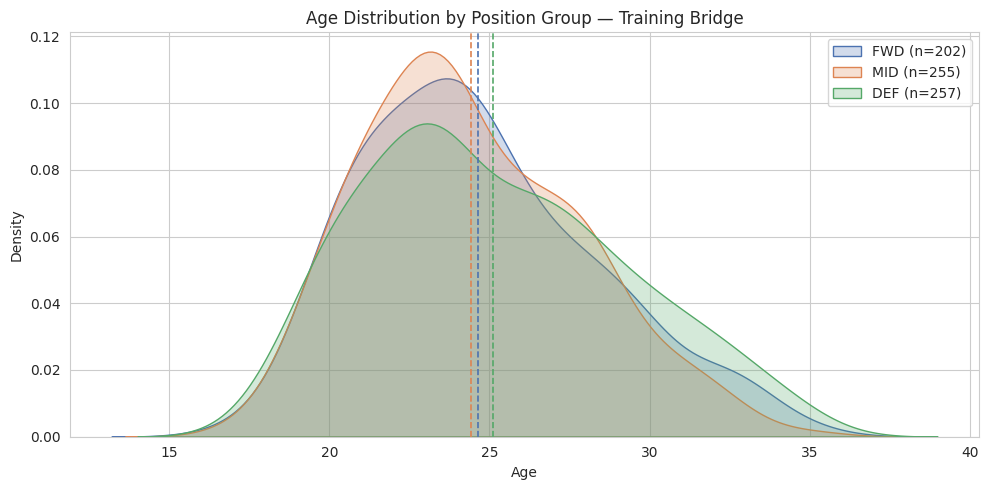

Age summary by position group:

  FWD:
    mean=24.7  median=24.0  std=3.7  min=17  max=35

  MID:
    mean=24.4  median=24.0  std=3.4  min=17  max=35

  DEF:
    mean=25.1  median=24.0  std=4.0  min=18  max=35


In [22]:
# ============================================================================
# CELL 9c: EDA — AGE DISTRIBUTION BY POSITION GROUP
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 5))
for label, df, color in [
    ('FWD', df_bridge_fwd, '#4c72b0'),
    ('MID', df_bridge_mid, '#dd8452'),
    ('DEF', df_bridge_def, '#55a868'),
]:
    ages = df['Age'].dropna()
    sns.kdeplot(ages, ax=ax, label=f"{label} (n={len(df)})",
                fill=True, alpha=0.25, color=color)
    ax.axvline(ages.mean(), color=color, linestyle='--', lw=1.2)

ax.set_title('Age Distribution by Position Group — Training Bridge', fontsize=12)
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

print("Age summary by position group:")
for label, df in [('FWD', df_bridge_fwd), ('MID', df_bridge_mid), ('DEF', df_bridge_def)]:
    stats = df['Age'].describe(percentiles=[.25, .5, .75]).round(1)
    print(f"\n  {label}:")
    print(f"    mean={stats['mean']:.1f}  median={stats['50%']:.1f}  "
          f"std={stats['std']:.1f}  min={stats['min']:.0f}  max={stats['max']:.0f}")

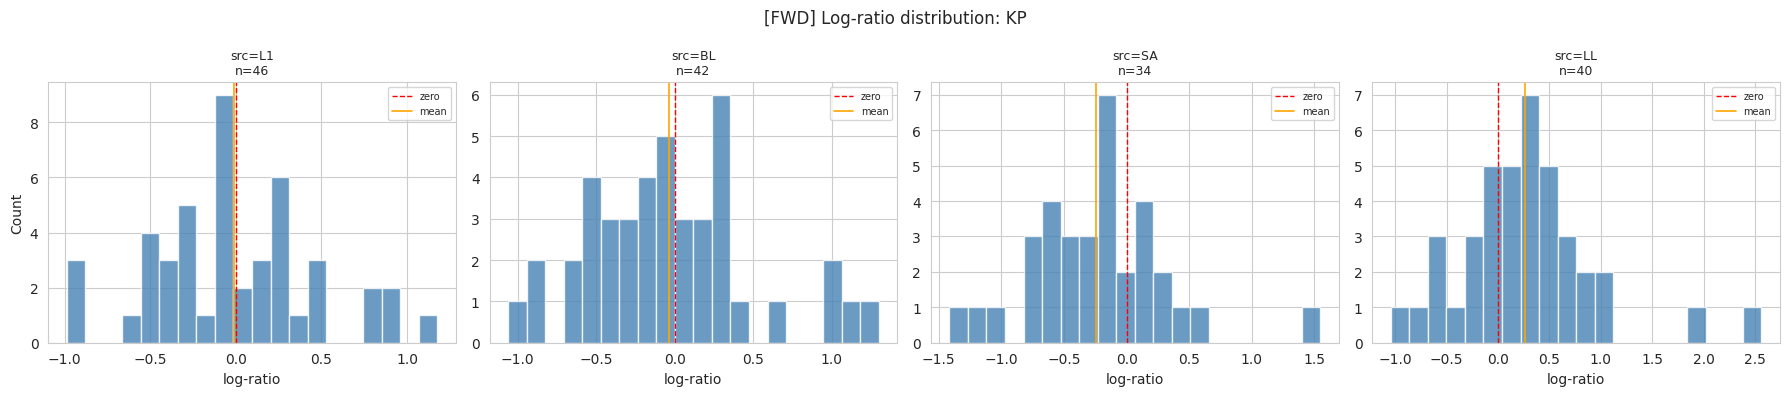

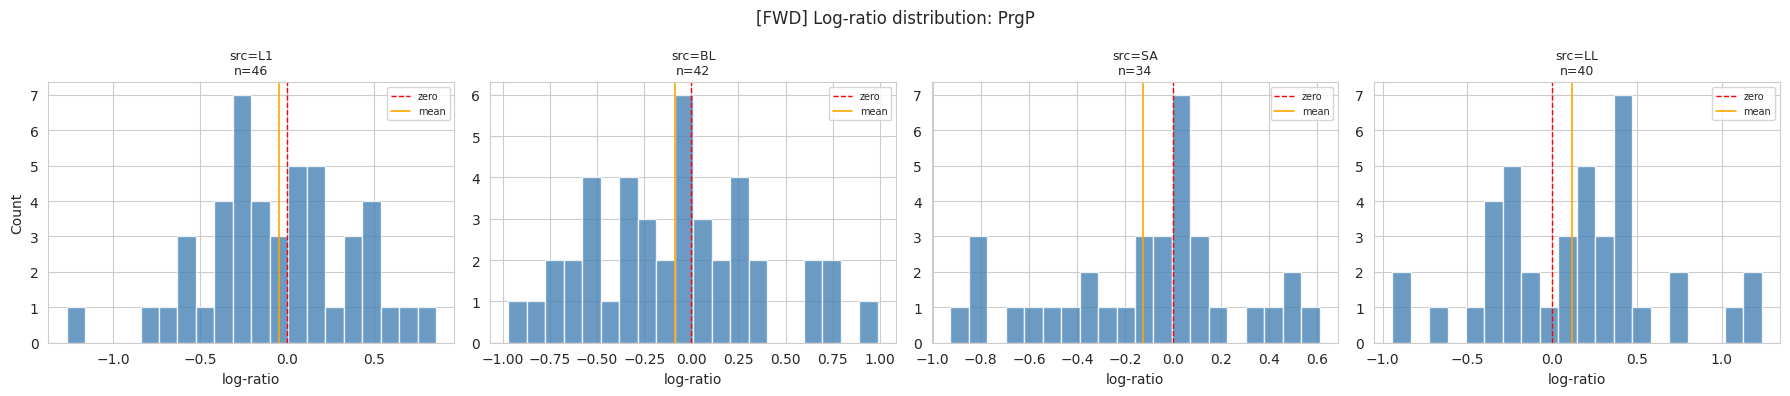

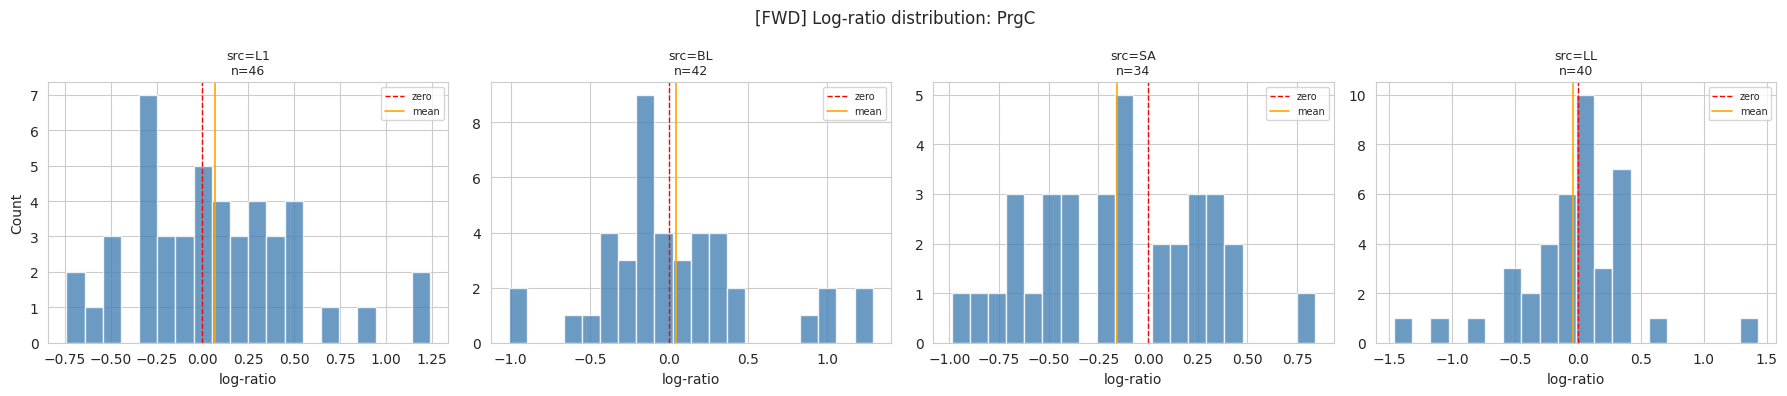

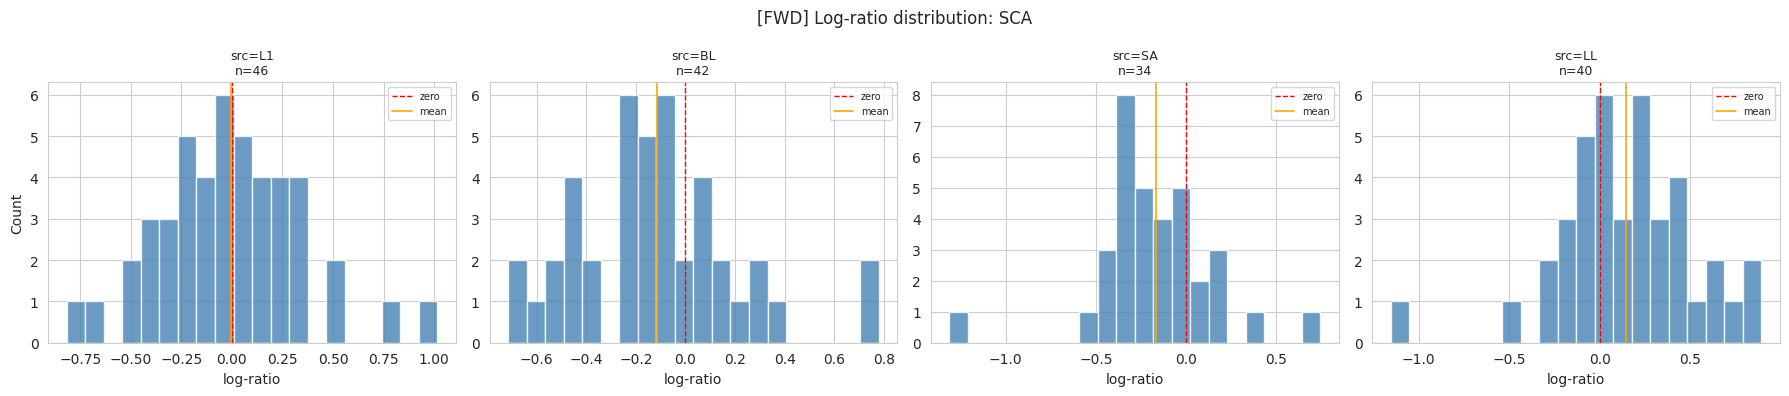

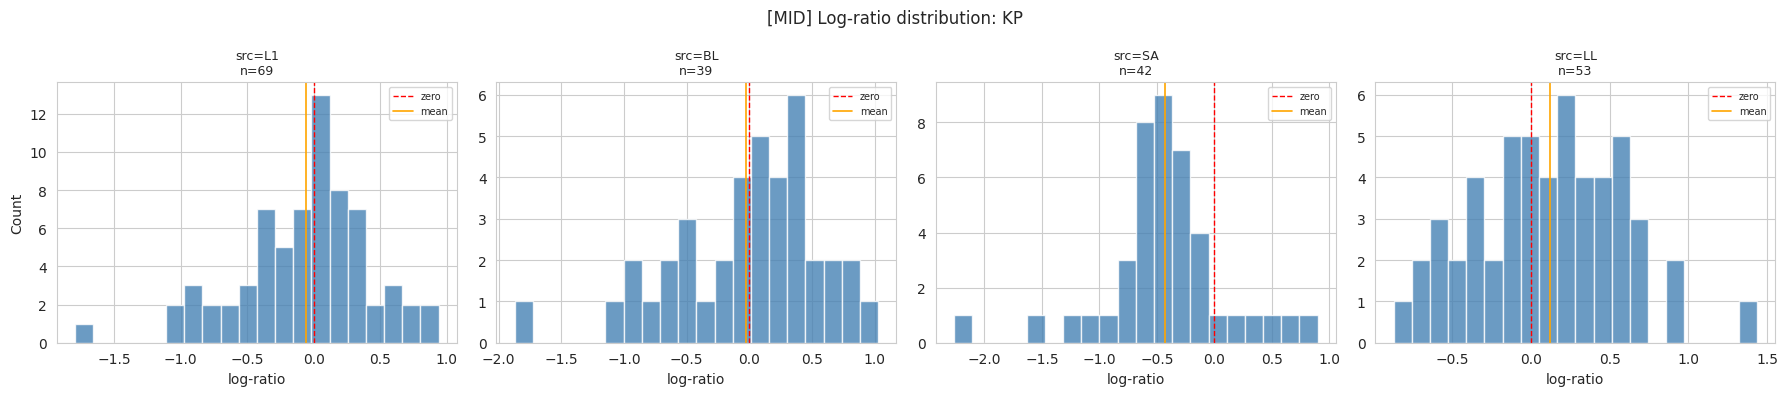

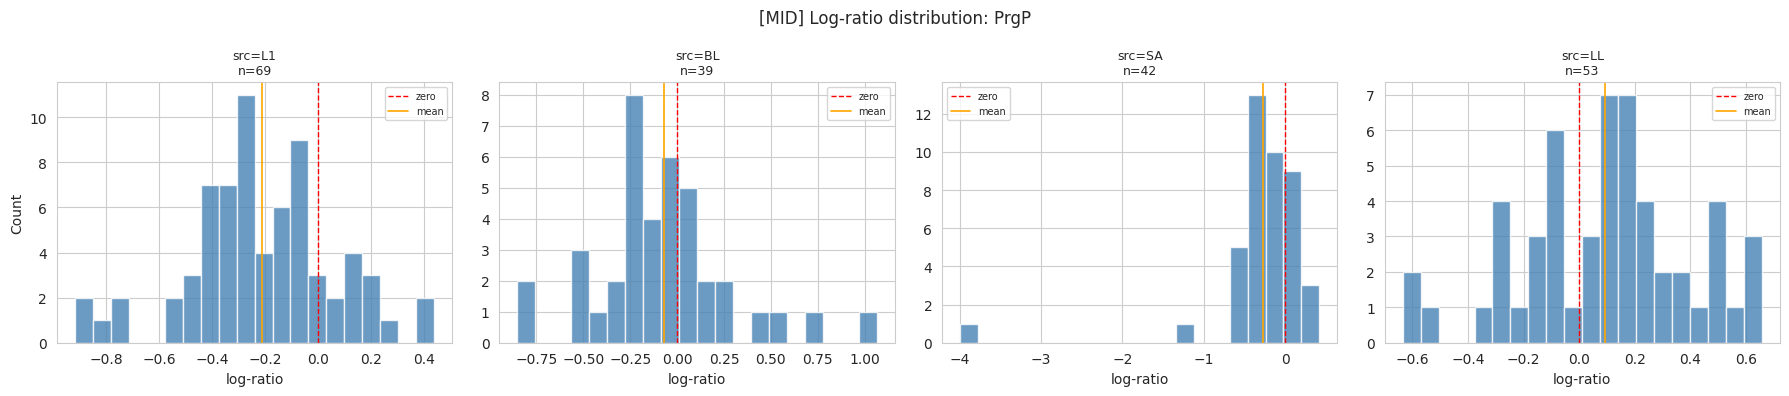

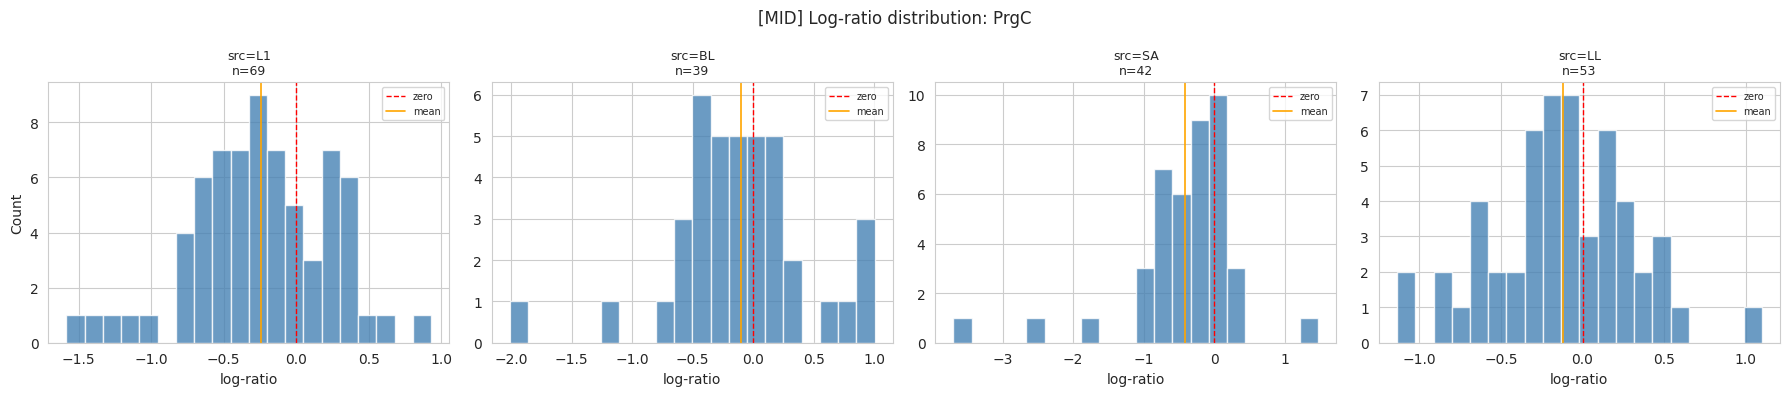

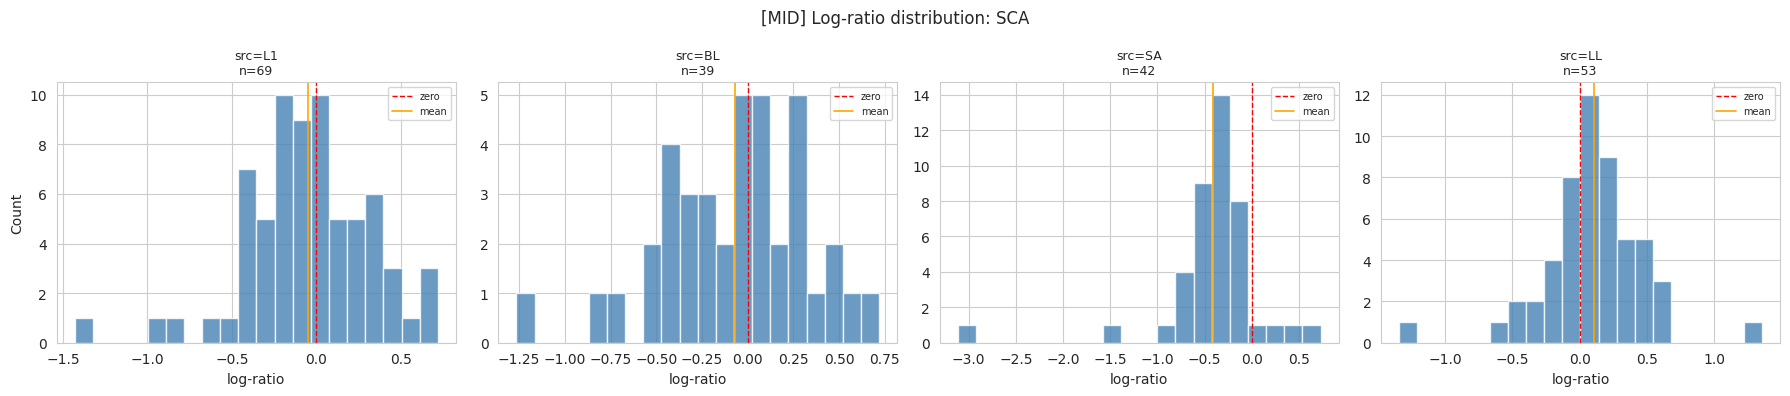

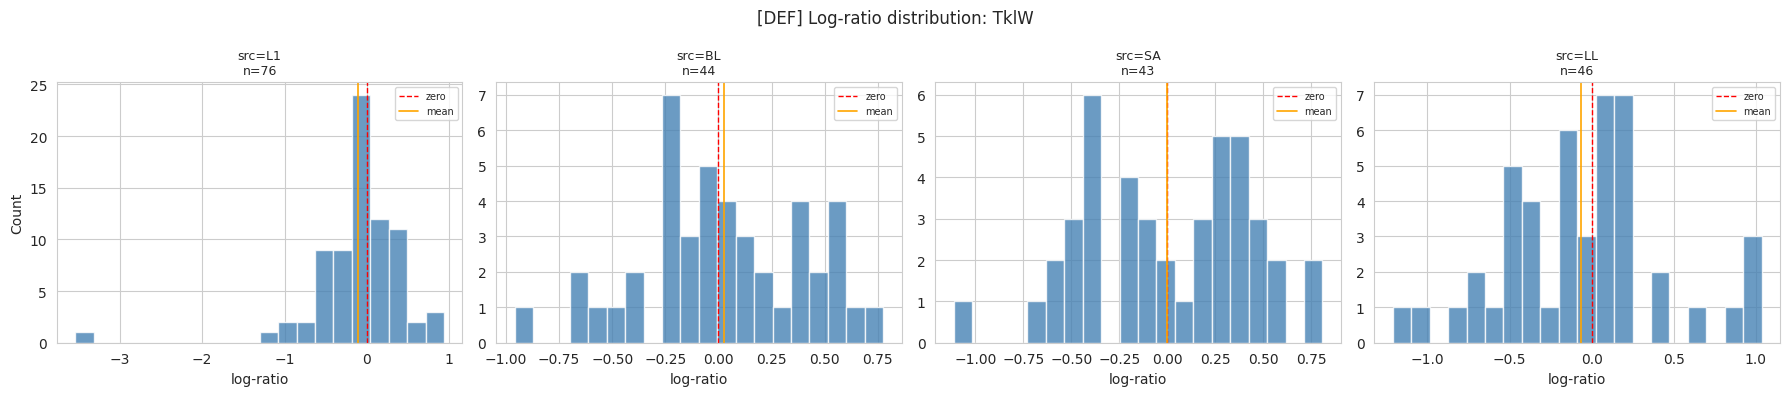

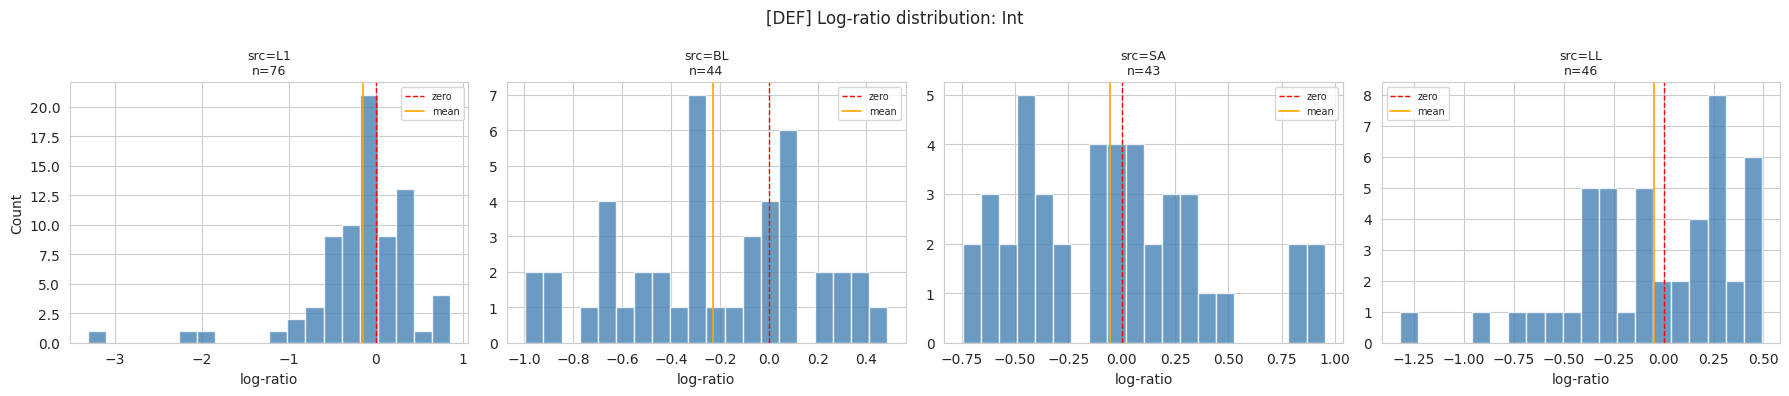

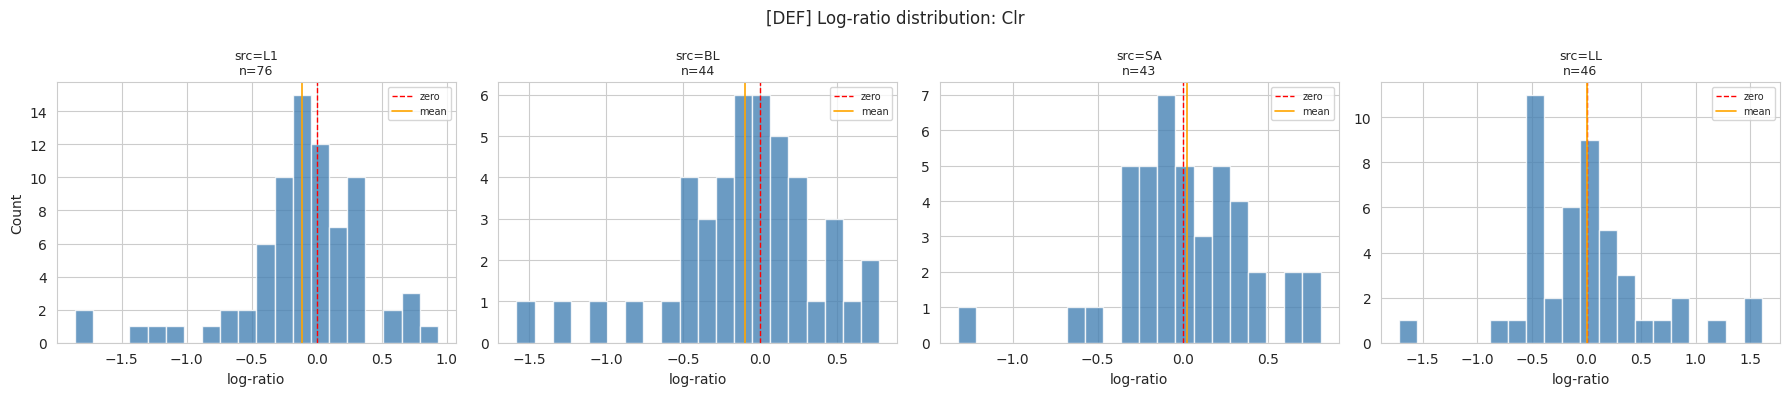

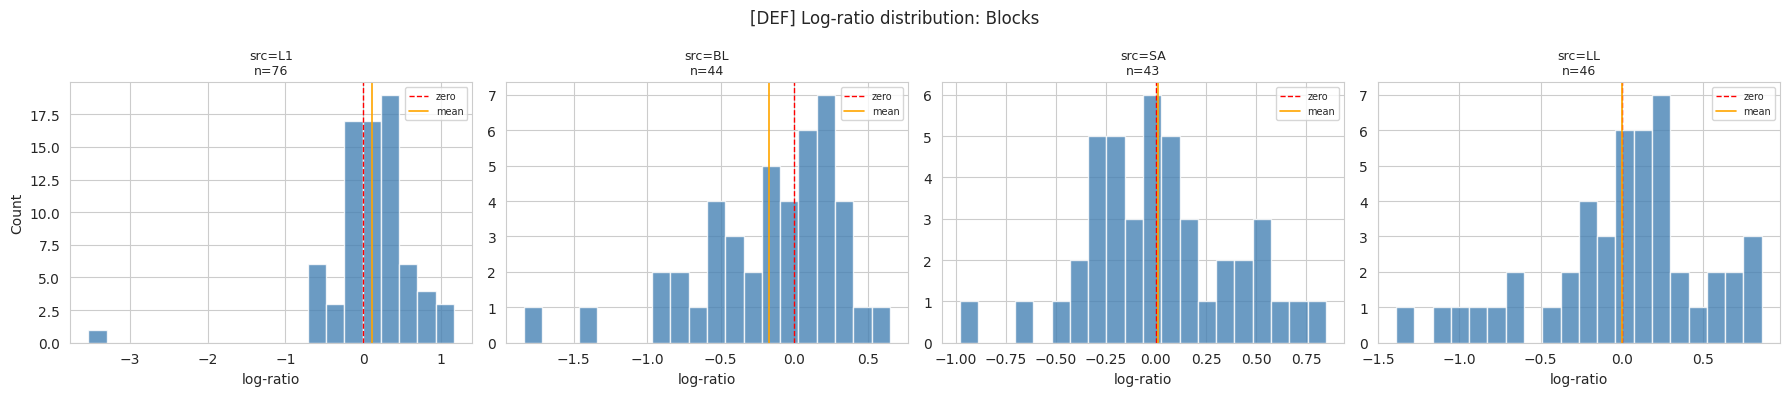

In [23]:
# ============================================================================
# CELL 9d: EDA — LOG-RATIO DISTRIBUTIONS BY SOURCE LEAGUE
# ============================================================================
# One figure per stat. Rows = source leagues, distributions show
# how log-ratios vary by where the player came from.

for pos_group, df, stats_list in [
    ('FWD', df_bridge_fwd, STATS_ATT_MID),
    ('MID', df_bridge_mid, STATS_ATT_MID),
    ('DEF', df_bridge_def, STATS_DEF),
]:
    for stat in stats_list:
        lr_col = f'log_ratio_{stat}'

        fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
        fig.suptitle(
            f'[{pos_group}] Log-ratio distribution: {stat}',
            fontsize=12
        )
        src_leagues = [l for l in VALID_LEAGUES if l != 'Premier League']

        for j, league in enumerate(src_leagues):
            subset = df[df['League_src'] == league][lr_col].dropna()
            axes[j].hist(subset, bins=20, color='steelblue',
                         edgecolor='white', alpha=0.8)
            axes[j].axvline(0, color='red', linestyle='--', lw=1,
                            label='zero')
            if len(subset) > 0:
                axes[j].axvline(subset.mean(), color='orange',
                                linestyle='-', lw=1.2, label='mean')
            axes[j].set_title(
                f'src={LEAGUE_ABBREV[league]}\nn={len(subset)}',
                fontsize=9
            )
            axes[j].set_xlabel('log-ratio')
            if j == 0:
                axes[j].set_ylabel('Count')
            axes[j].legend(fontsize=7)

        plt.tight_layout()
        plt.show()

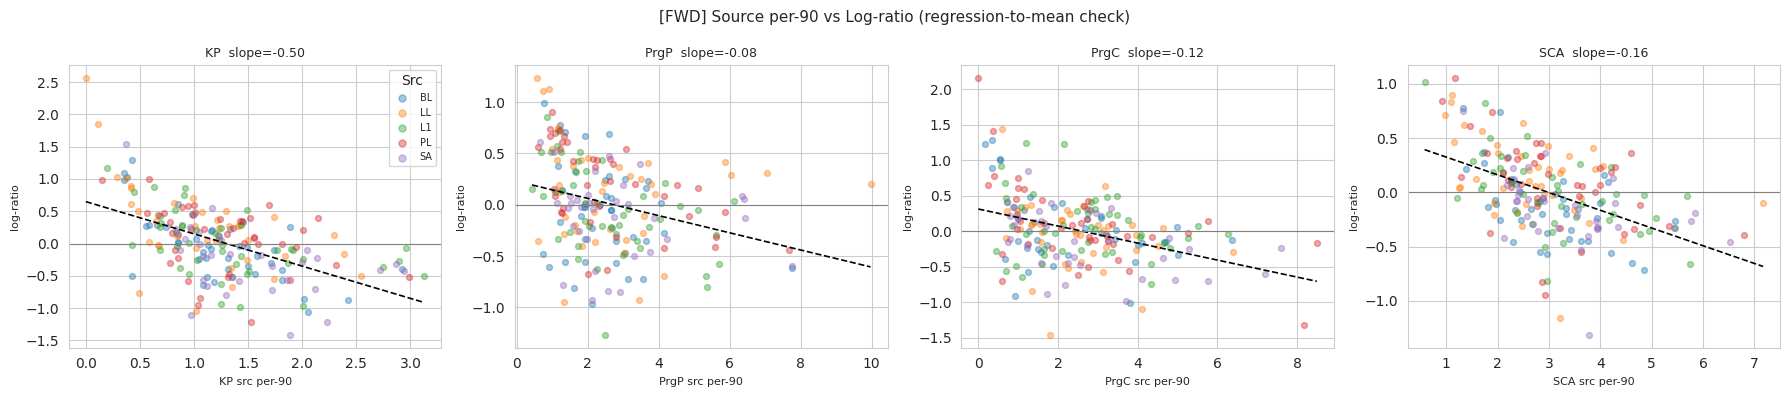

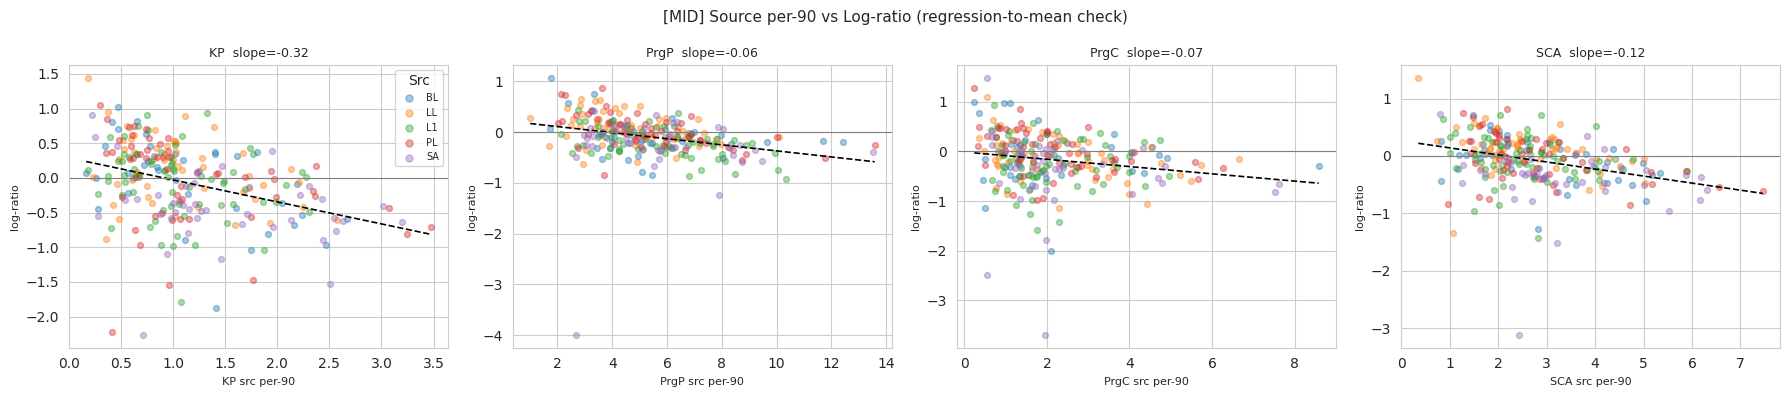

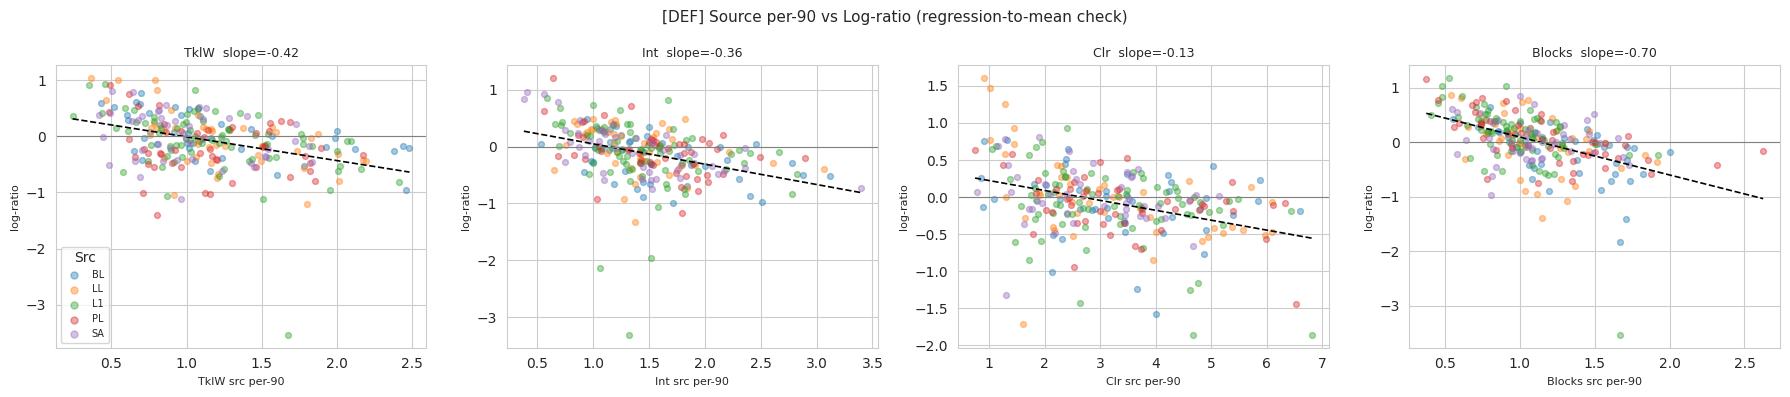

In [24]:
# ============================================================================
# CELL 9e: EDA — SOURCE PER-90 vs LOG-RATIO
# ============================================================================
# Checks regression-to-mean signal: negative slope expected.
# Coloured by source league to reveal league-specific patterns.

for pos_group, df, stats_list in [
    ('FWD', df_bridge_fwd, STATS_ATT_MID),
    ('MID', df_bridge_mid, STATS_ATT_MID),
    ('DEF', df_bridge_def, STATS_DEF),
]:
    fig, axes = plt.subplots(1, len(stats_list), figsize=(18, 4))
    fig.suptitle(
        f'[{pos_group}] Source per-90 vs Log-ratio (regression-to-mean check)',
        fontsize=11
    )

    for i, stat in enumerate(stats_list):
        src_col = f'{stat}_src_per90'
        lr_col  = f'log_ratio_{stat}'
        ax      = axes[i]

        for league, grp in df.groupby('League_src'):
            ax.scatter(
                grp[src_col], grp[lr_col],
                alpha=0.4, s=18,
                label=LEAGUE_ABBREV[league],
            )

        # OLS trend line
        x = df[src_col].values
        y = df[lr_col].values
        valid = np.isfinite(x) & np.isfinite(y)
        if valid.sum() > 5 and np.std(x[valid]) > 1e-6:
            try:
                m, b = np.polyfit(x[valid], y[valid], 1)
                xr = np.linspace(x[valid].min(), x[valid].max(), 100)
                ax.plot(xr, m * xr + b, 'k--', lw=1.2)
                ax.set_title(f'{stat}  slope={m:.2f}', fontsize=9)
            except np.linalg.LinAlgError:
                ax.set_title(f'{stat}  (fit failed)', fontsize=9)
        else:
            ax.set_title(f'{stat}  (low variance)', fontsize=9)

        ax.axhline(0, color='gray', lw=0.8)
        ax.set_xlabel(f'{stat} src per-90', fontsize=8)
        ax.set_ylabel('log-ratio', fontsize=8)

    axes[0].legend(title='Src', fontsize=7, markerscale=1.2)
    plt.tight_layout()
    plt.show()

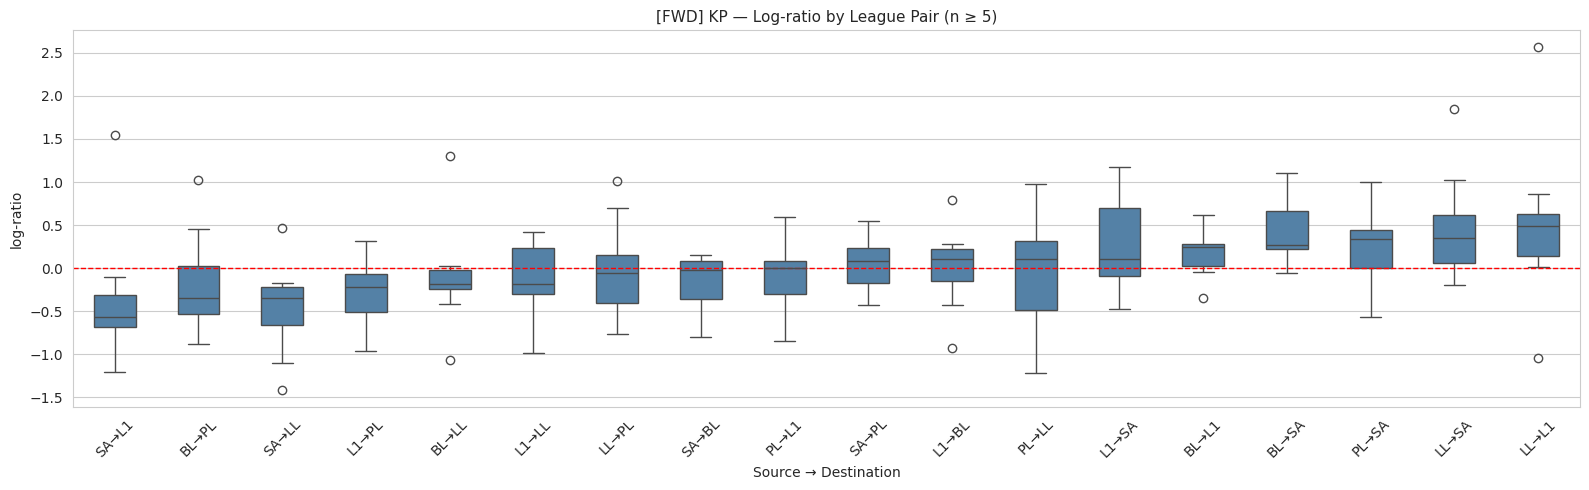

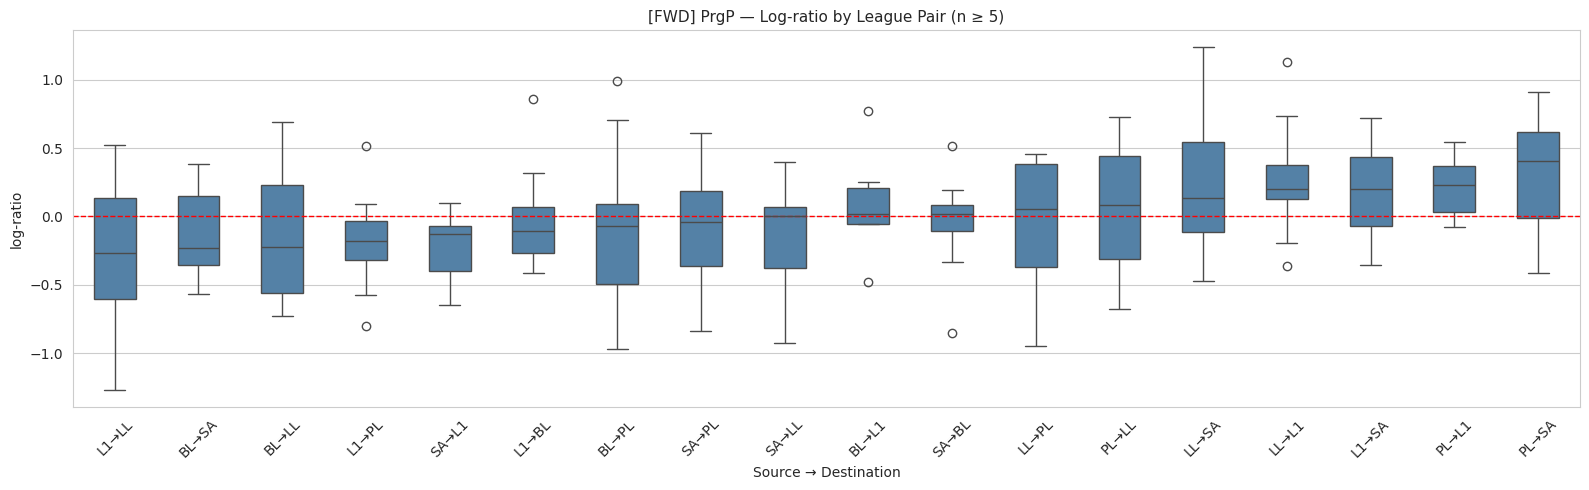

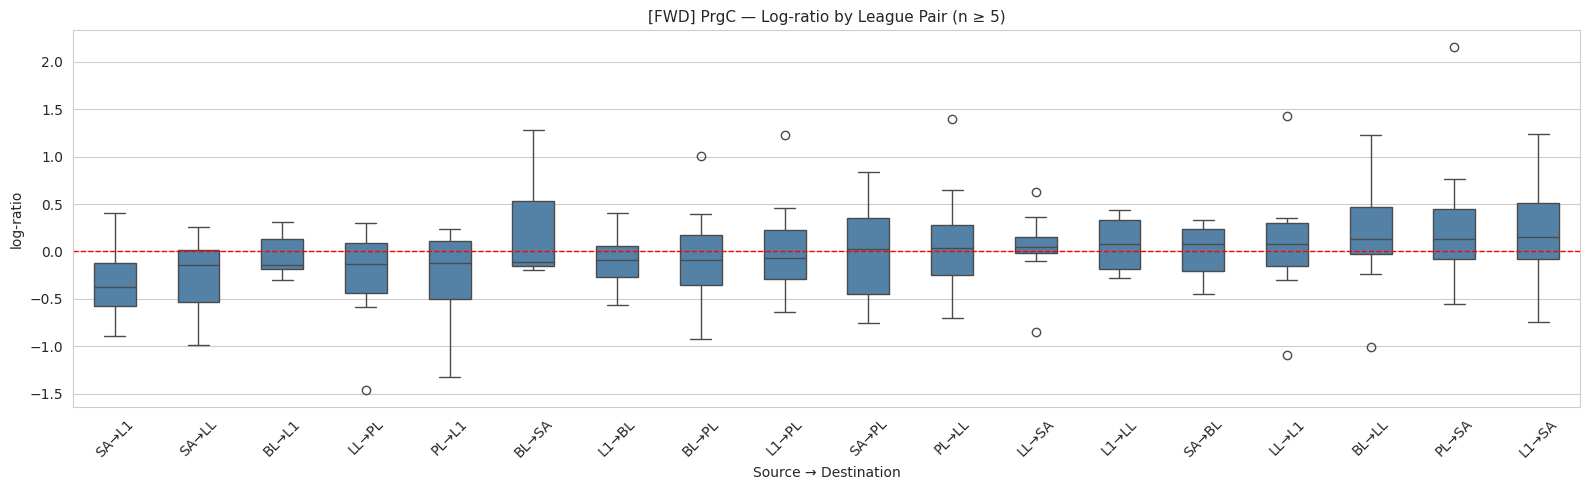

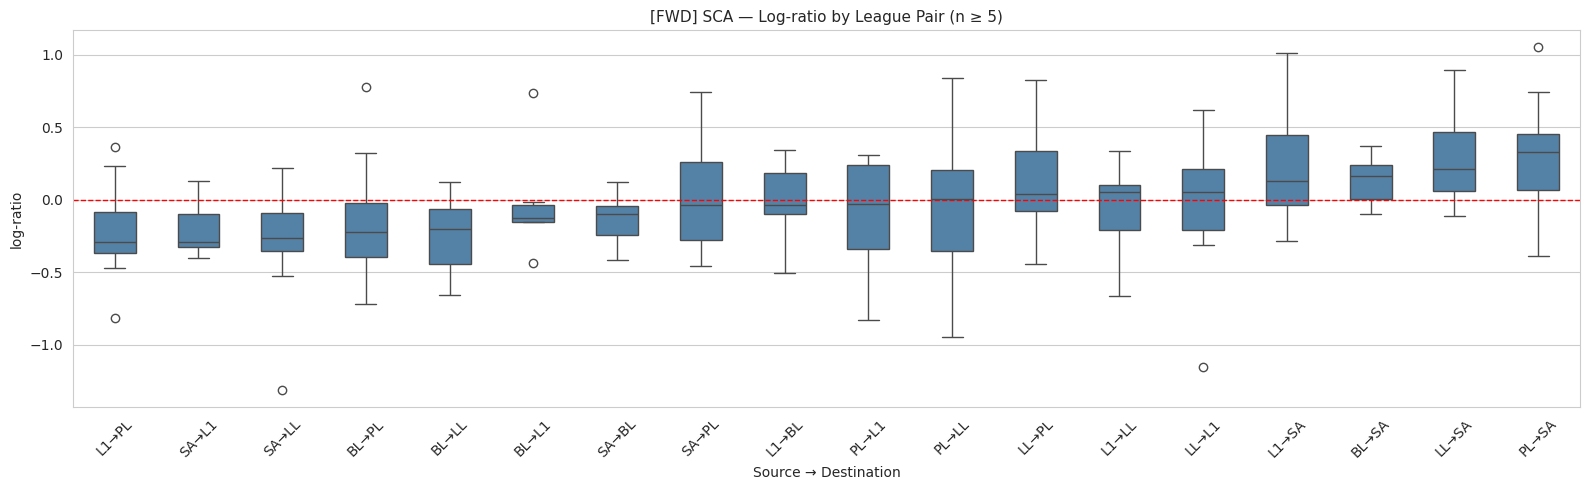

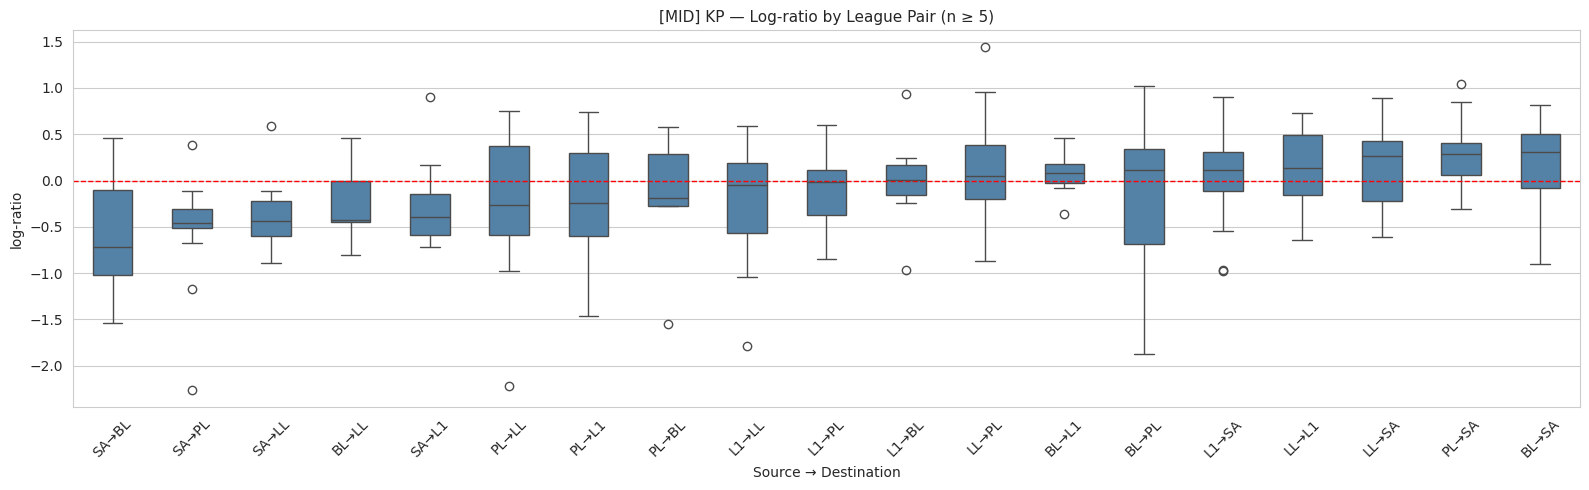

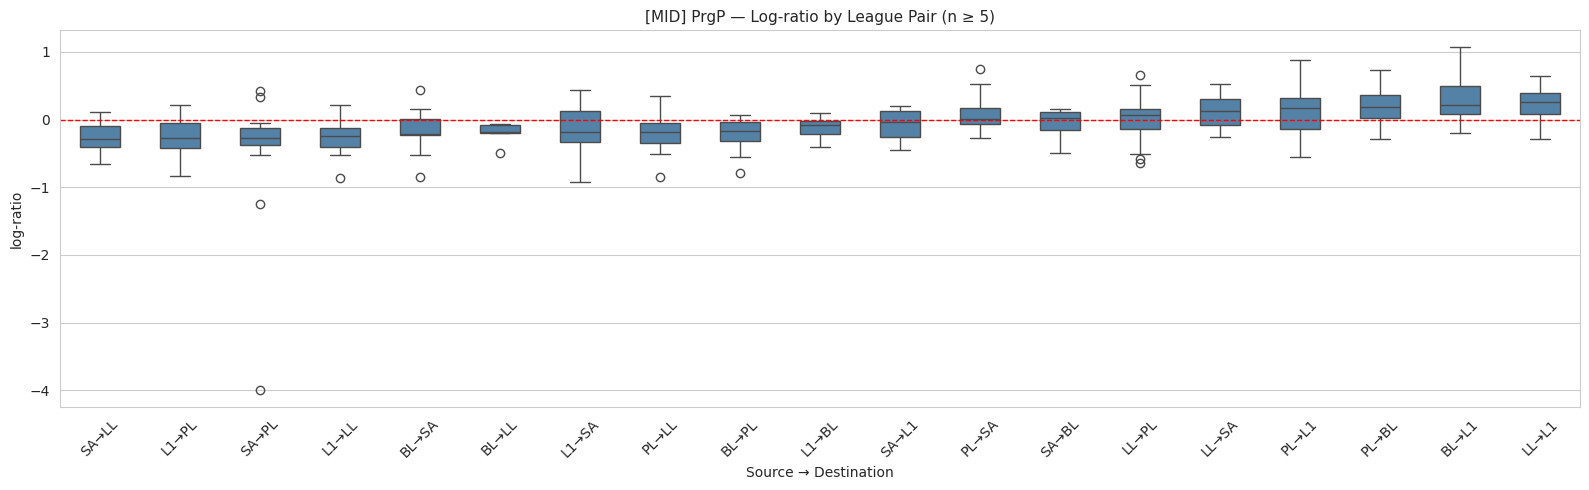

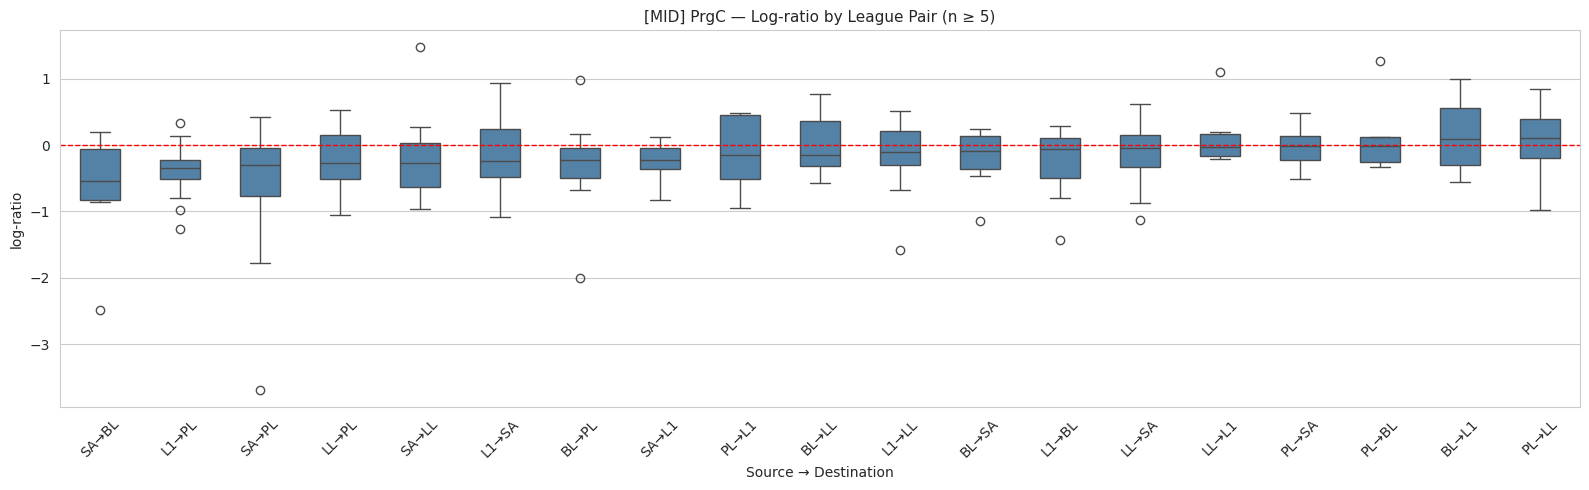

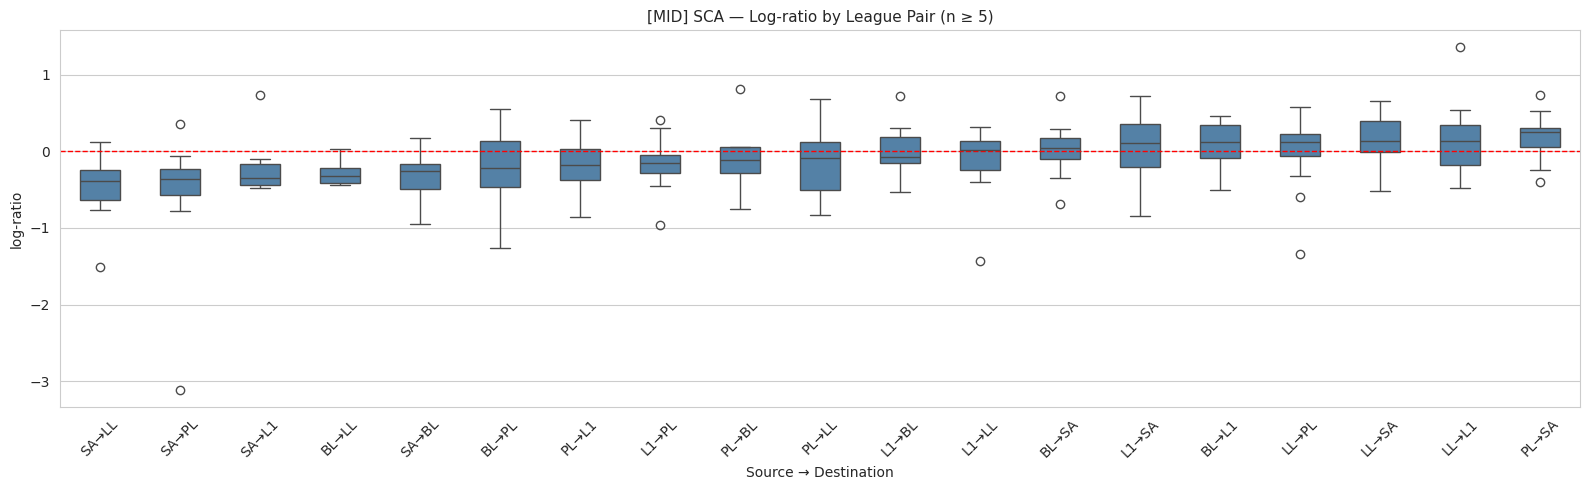

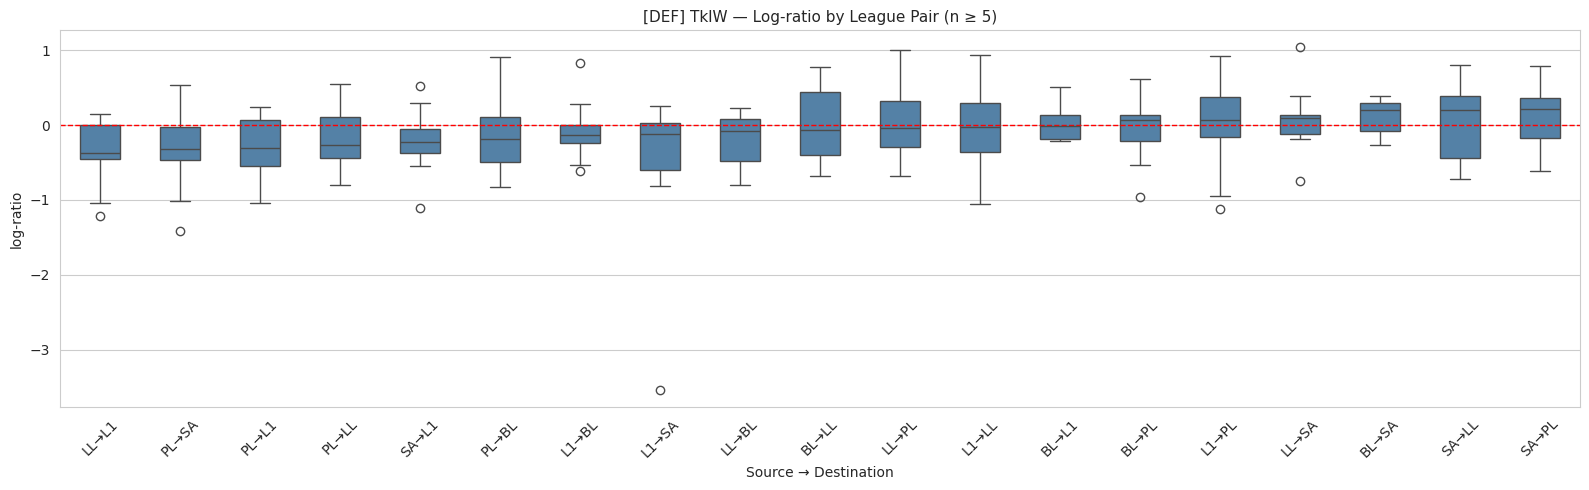

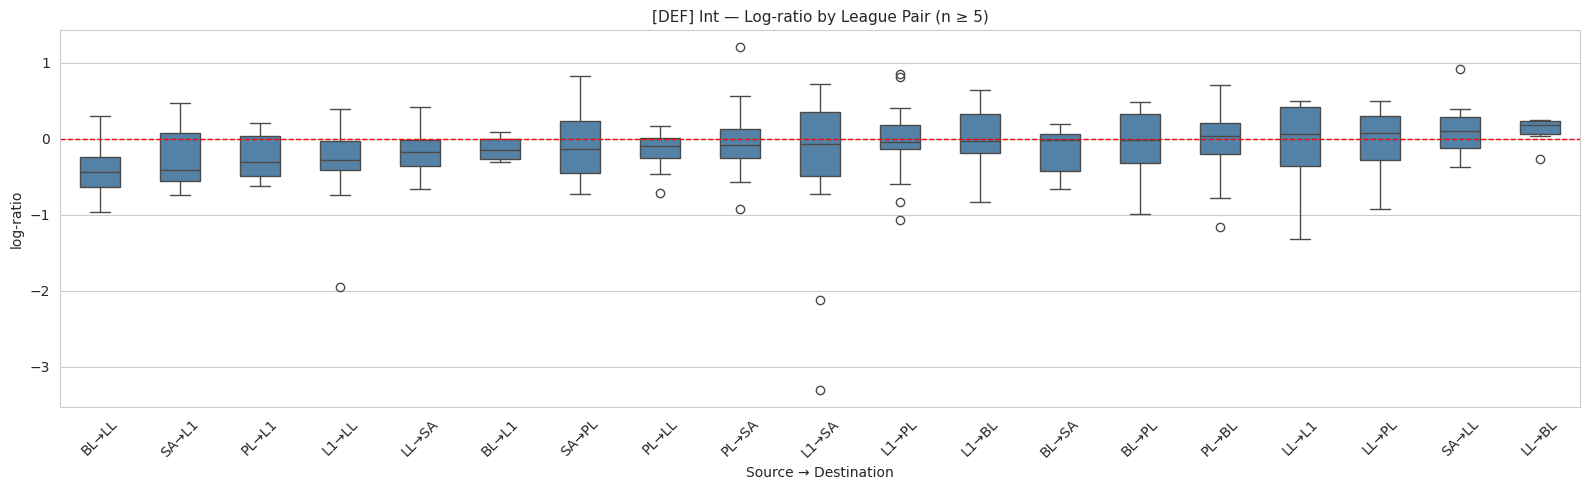

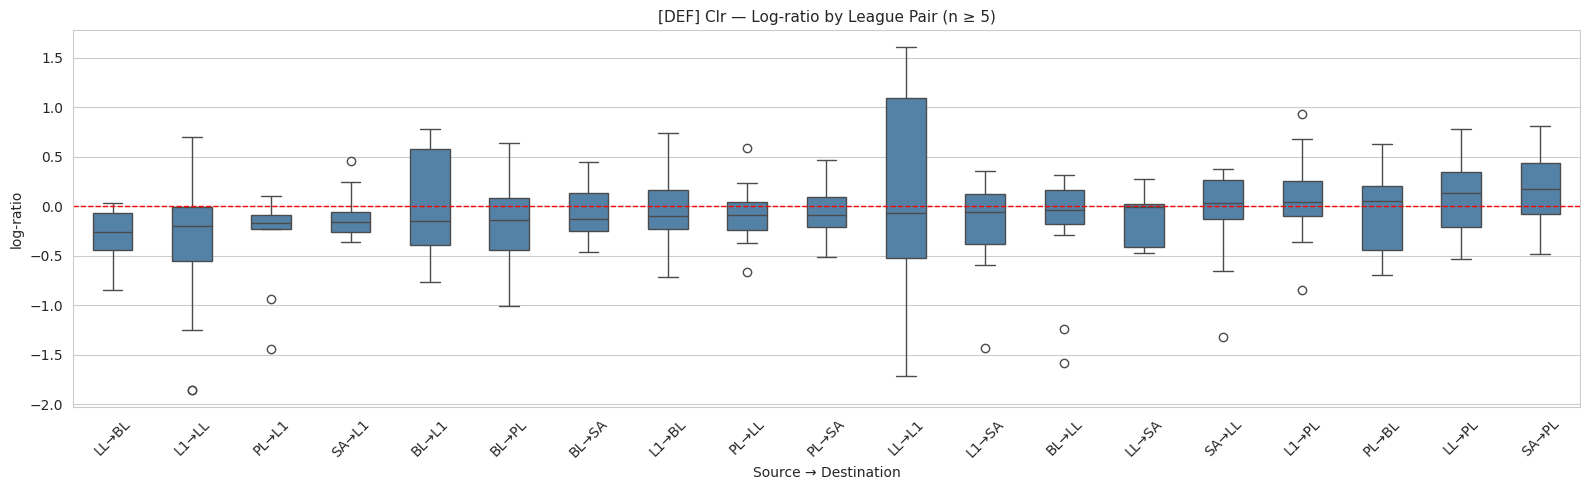

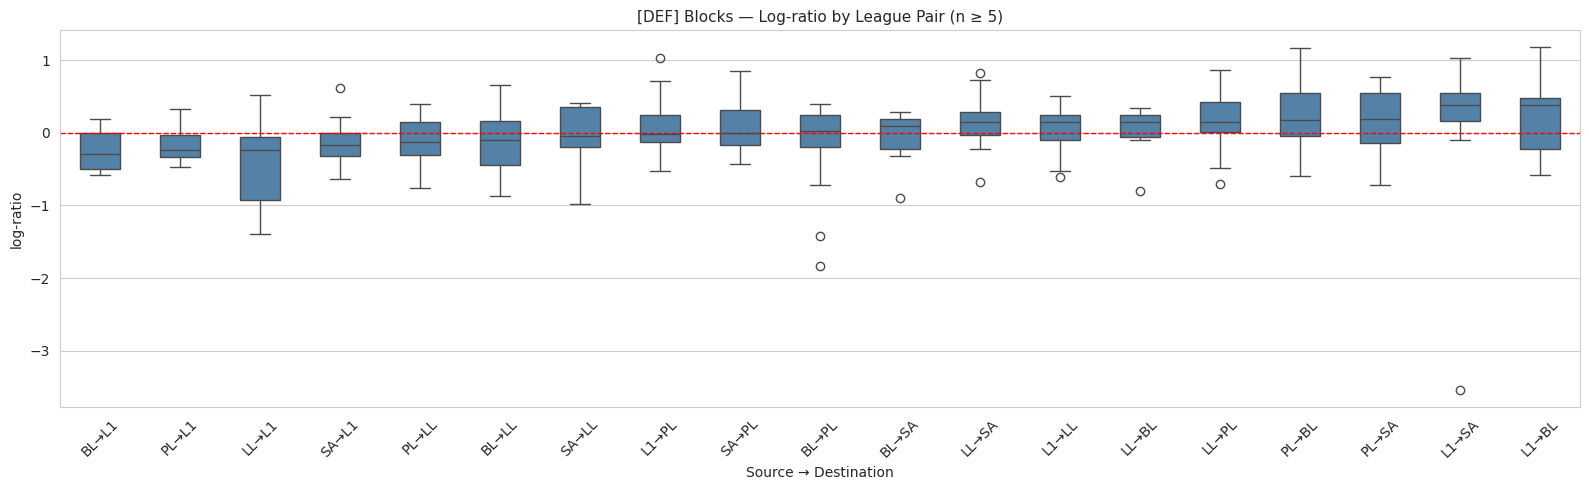

In [25]:
# ============================================================================
# CELL 9f: EDA — LOG-RATIO BY LEAGUE PAIR (BOXPLOT)
# ============================================================================
# Shows translation difficulty per src→trg pair.
# Only pairs with n >= 5 shown to avoid single-observation boxes.

for pos_group, df, stats_list in [
    ('FWD', df_bridge_fwd, STATS_ATT_MID),
    ('MID', df_bridge_mid, STATS_ATT_MID),
    ('DEF', df_bridge_def, STATS_DEF),
]:
    for stat in stats_list:
        lr_col = f'log_ratio_{stat}'
        plot_df = df[['League_src', 'League_trg', lr_col]].dropna().copy()
        plot_df['Pair'] = (
            plot_df['League_src'].map(LEAGUE_ABBREV) + '→' +
            plot_df['League_trg'].map(LEAGUE_ABBREV)
        )
        pair_sizes  = plot_df['Pair'].value_counts()
        valid_pairs = pair_sizes[pair_sizes >= 5].index
        plot_df     = plot_df[plot_df['Pair'].isin(valid_pairs)]

        if len(plot_df) == 0:
            print(f"[{pos_group}] {stat}: no pairs with n >= 5, skipping.")
            continue

        order = (
            plot_df.groupby('Pair')[lr_col]
                   .median()
                   .sort_values()
                   .index.tolist()
        )

        fig, ax = plt.subplots(figsize=(16, 5))
        sns.boxplot(data=plot_df, x='Pair', y=lr_col, order=order,
                    ax=ax, color='steelblue', width=0.5)
        ax.axhline(0, color='red', linestyle='--', lw=1)
        ax.set_title(
            f'[{pos_group}] {stat} — Log-ratio by League Pair (n ≥ 5)',
            fontsize=11
        )
        ax.set_xlabel('Source → Destination')
        ax.set_ylabel('log-ratio')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

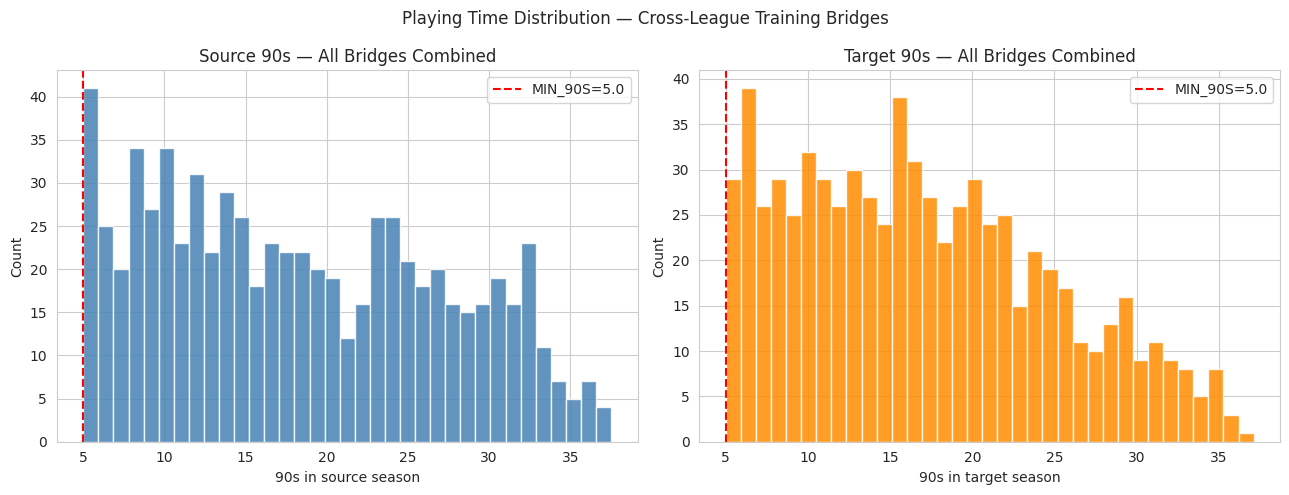

90s_src quantiles:
count    714.0
mean      18.3
std        8.8
min        5.0
10%        7.1
25%       10.5
50%       17.2
75%       25.4
90%       31.0
max       37.5
Name: 90s_src, dtype: float64

90s_trg quantiles:
count    714.0
mean      17.0
std        7.8
min        5.0
10%        7.0
25%       10.5
50%       16.1
75%       22.4
90%       28.7
max       37.1
Name: 90s_trg, dtype: float64


In [26]:
# ============================================================================
# CELL 9g: EDA — PLAYING TIME DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

all_train = pd.concat([df_bridge_fwd, df_bridge_mid, df_bridge_def], ignore_index=True)

axes[0].hist(all_train['90s_src'], bins=35, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(MIN_90S, color='red', linestyle='--', lw=1.5,
                label=f'MIN_90S={MIN_90S}')
axes[0].set_title('Source 90s — All Bridges Combined')
axes[0].set_xlabel('90s in source season')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(all_train['90s_trg'], bins=35, color='darkorange',
             edgecolor='white', alpha=0.85)
axes[1].axvline(MIN_90S, color='red', linestyle='--', lw=1.5,
                label=f'MIN_90S={MIN_90S}')
axes[1].set_title('Target 90s — All Bridges Combined')
axes[1].set_xlabel('90s in target season')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Playing Time Distribution — Cross-League Training Bridges', fontsize=12)
plt.tight_layout()
plt.show()

print("90s_src quantiles:")
print(all_train['90s_src'].describe(percentiles=[.1, .25, .5, .75, .9]).round(1))
print("\n90s_trg quantiles:")
print(all_train['90s_trg'].describe(percentiles=[.1, .25, .5, .75, .9]).round(1))

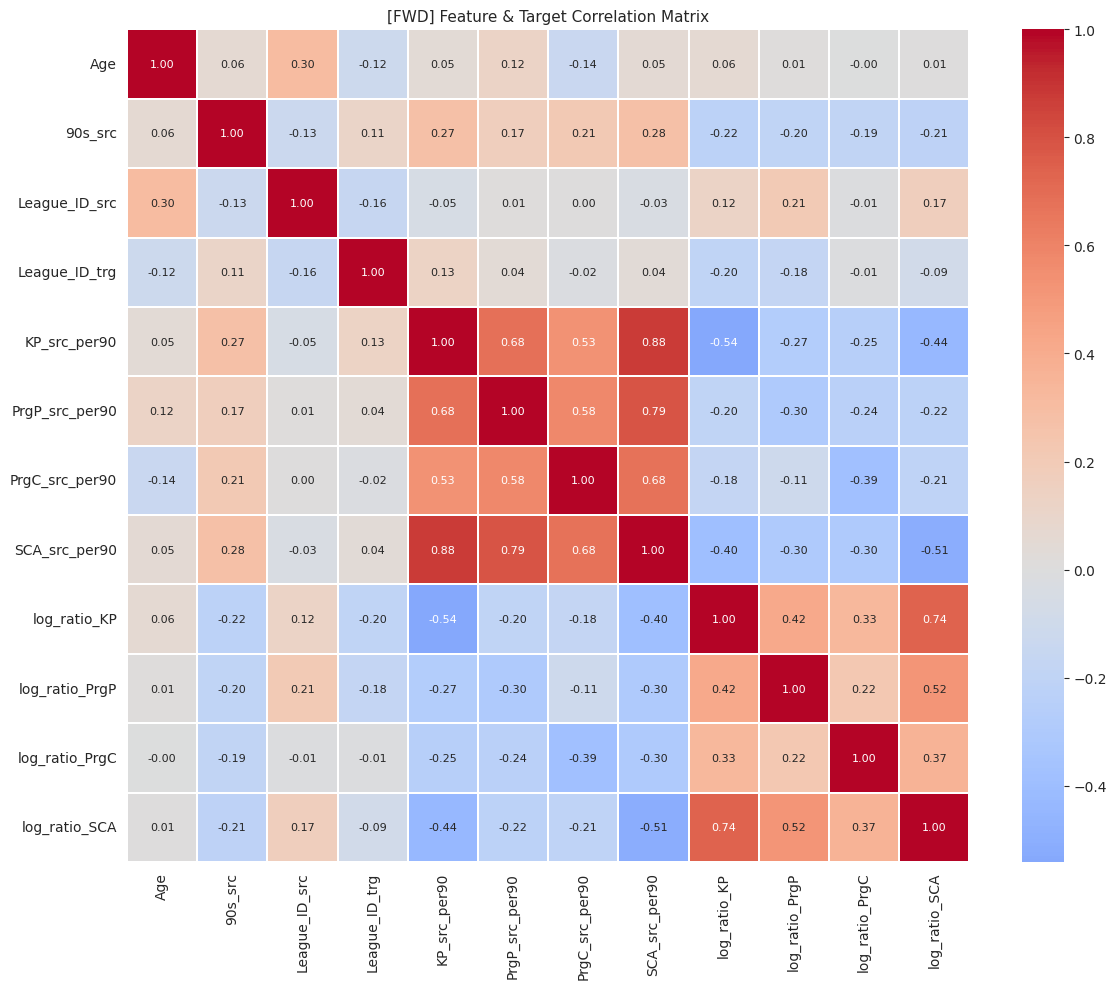

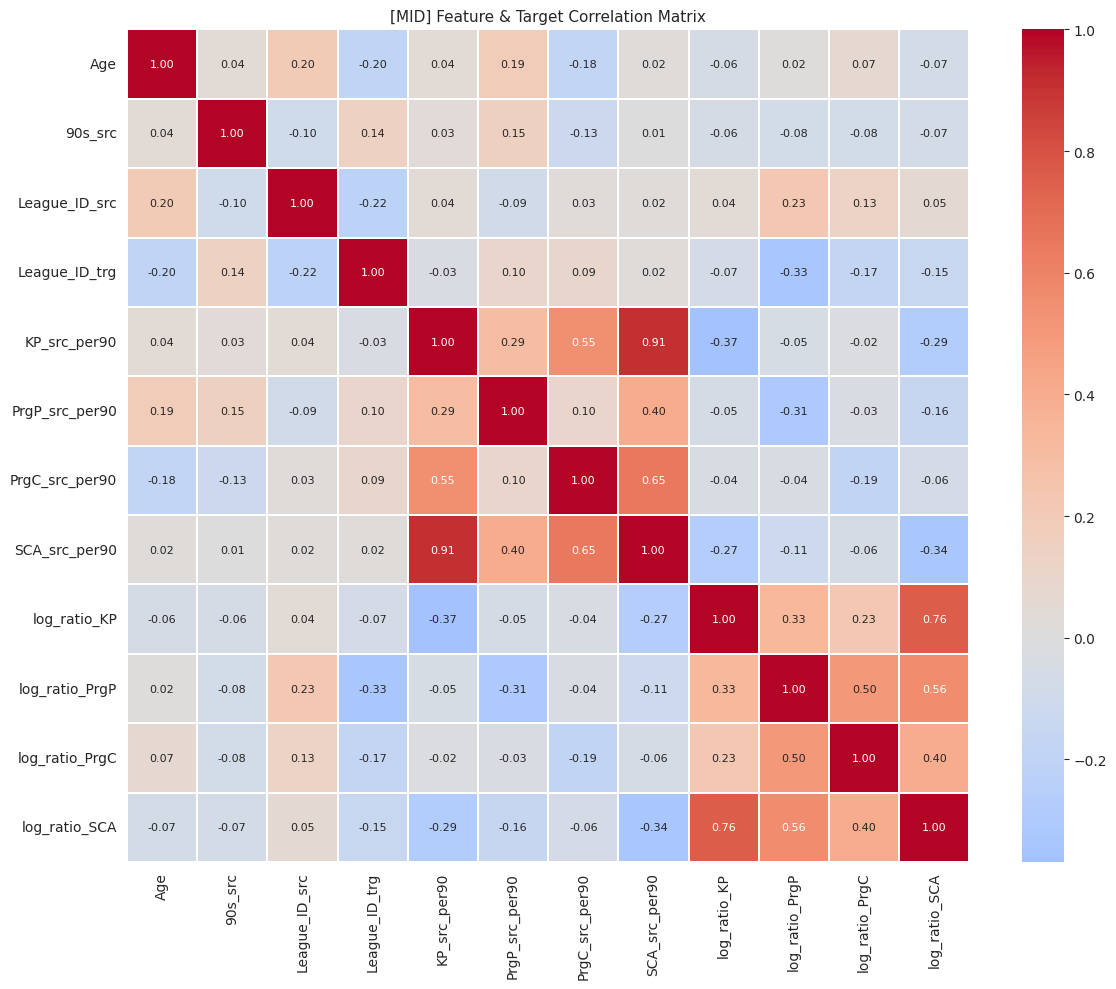

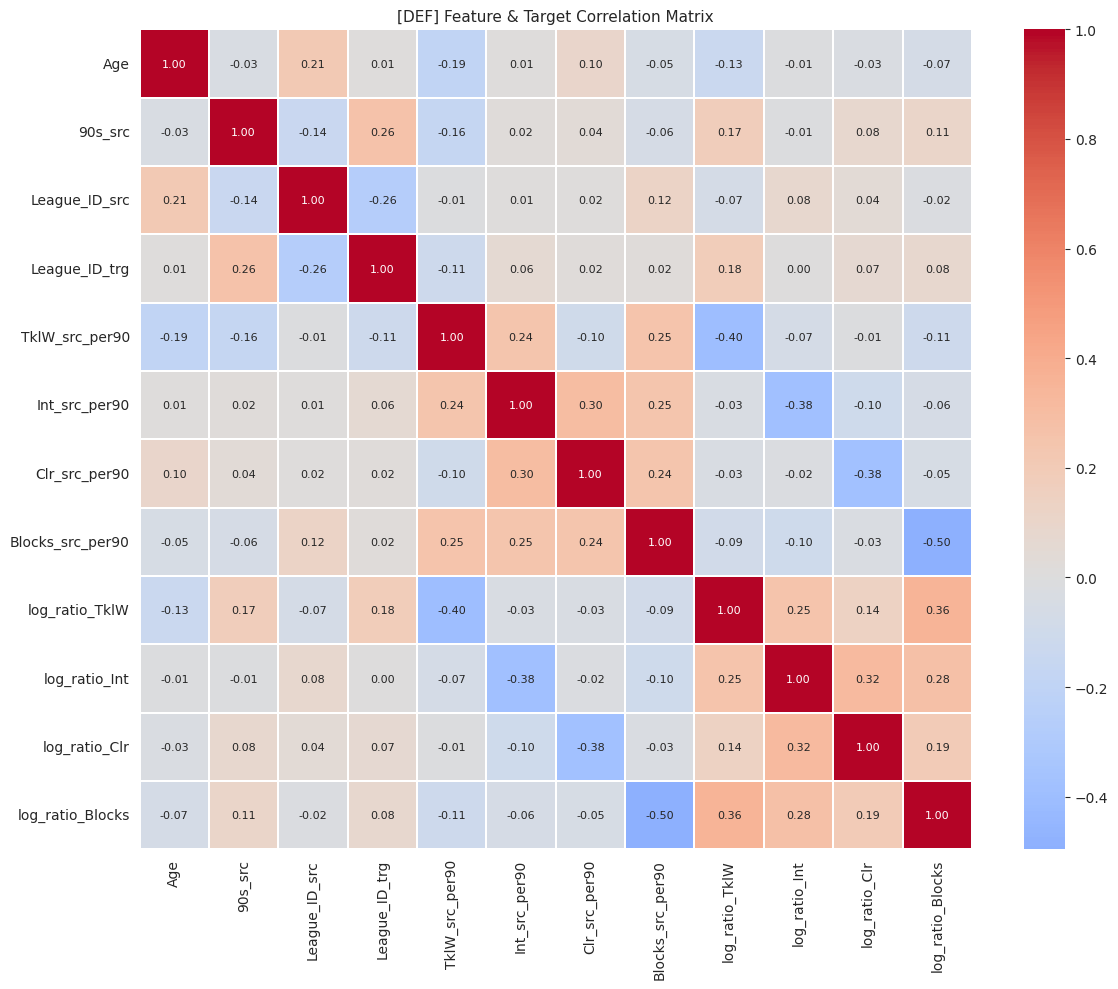

In [27]:
# ============================================================================
# CELL 9h: EDA — FEATURE CORRELATION HEATMAP (per position group)
# ============================================================================

for pos_group, df, stats_list in [
    ('FWD', df_bridge_fwd, STATS_ATT_MID),
    ('MID', df_bridge_mid, STATS_ATT_MID),
    ('DEF', df_bridge_def, STATS_DEF),
]:
    feature_cols = ['Age', '90s_src', 'League_ID_src', 'League_ID_trg']
    feature_cols += [f'{s}_src_per90' for s in stats_list]
    target_cols  = [f'log_ratio_{s}' for s in stats_list]

    corr_df = df[feature_cols + target_cols].dropna()
    corr_matrix = corr_df.corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        annot=True, fmt='.2f', cmap='coolwarm',
        center=0, linewidths=0.3, ax=ax,
        annot_kws={'size': 8},
    )
    ax.set_title(
        f'[{pos_group}] Feature & Target Correlation Matrix',
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

In [28]:
# ============================================================================
# CELL 10: SAVE BRIDGES & METADATA
# ============================================================================

saves = [
    ('ml_bridge_train_fwd.csv', df_bridge_fwd),
    ('ml_bridge_train_mid.csv', df_bridge_mid),
    ('ml_bridge_train_def.csv', df_bridge_def),
    ('ml_bridge_test_fwd.csv',  df_test_fwd),
    ('ml_bridge_test_mid.csv',  df_test_mid),
    ('ml_bridge_test_def.csv',  df_test_def),
]

print("Saving bridges...")
for fname, df in saves:
    df.to_csv(fname, index=False)
    print(f"  {fname:<35s} — {len(df):>4d} rows, {len(df.columns):>3d} cols")

# Save position-to-stat mapping for modelling notebook
with open('pos_stat_map.json', 'w') as f:
    json.dump(POS_STAT_MAP, f, indent=2)
print("\nSaved pos_stat_map.json")

# Final temporal holdout check across all training bridges
print("\nTemporal holdout verification:")
for label, df in [('FWD', df_bridge_fwd), ('MID', df_bridge_mid), ('DEF', df_bridge_def)]:
    leaked = set(df['Transfer_Season']) & _orig_excl
    assert len(leaked) == 0, f"LEAK in {label}: {leaked}"
    seasons_seen = sorted(df['Transfer_Season'].unique())
    print(f"  {label}: seasons in bridge = {seasons_seen}")

print("\nAll saves complete. No temporal leakage detected.")

Saving bridges...
  ml_bridge_train_fwd.csv             —  202 rows,  30 cols
  ml_bridge_train_mid.csv             —  255 rows,  30 cols
  ml_bridge_train_def.csv             —  257 rows,  30 cols
  ml_bridge_test_fwd.csv              —   82 rows,  31 cols
  ml_bridge_test_mid.csv              —  109 rows,  31 cols
  ml_bridge_test_def.csv              —  135 rows,  31 cols

Saved pos_stat_map.json

Temporal holdout verification:
  FWD: seasons in bridge = ['2017_2018_to_2018_2019', '2018_2019_to_2019_2020', '2019_2020_to_2020_2021', '2020_2021_to_2021_2022', '2021_2022_to_2022_2023']
  MID: seasons in bridge = ['2017_2018_to_2018_2019', '2018_2019_to_2019_2020', '2019_2020_to_2020_2021', '2020_2021_to_2021_2022', '2021_2022_to_2022_2023']
  DEF: seasons in bridge = ['2017_2018_to_2018_2019', '2018_2019_to_2019_2020', '2019_2020_to_2020_2021', '2020_2021_to_2021_2022', '2021_2022_to_2022_2023']

All saves complete. No temporal leakage detected.
